# NDVI Fire-Susceptibility Feature Pipeline (v2) -- GPU Accelerated
## Step 2: NDVI analysis -- India (2000-2022)
### Reference: Biswas et al. (2025), *Environ. Sci. Pollut. Res.*, 32:4856-4878

**Data:** MOD13A3.061, monthly 1 km NDVI + pixel_reliability + VI_Quality, NASA AppEEARS
**Study period:** 1 Nov 2000 - 15 Dec 2022 (266 months) -- **matches Step 1 exactly**
**Grid:** this notebook establishes the NDVI grid (3641 x 3504 px, EPSG:4326, ~0.0083 deg / 1 km)
that Steps 3, 4, 5 and 6 reproject onto. `F1_NDVI_QA_mean.tif` is the grid reference file.

---
### v2 definitions (2026-09-25 methodology audit)

This version implements the corrected definitions established by the completed end-to-end audit
(project root `results/FULL_METHODOLOGY_AUDIT.md`, section *Step 7 -- NDVI*; this repository's
`AUDIT_2026-09-25.md`). The audit recalculated every historical (v1) output from the 266 raw
MOD13A3.061 months and reproduced them all, then identified the problems below.

| Item | v1 problem (audit finding) | v2 definition in this notebook |
|---|---|---|
| QA gap | 2007-03 and 2007-04 have **no pixel_reliability file** (a 2025-03 file was downloaded instead); v1 used those two months **unfiltered** | For months with no pixel_reliability layer, the VI_Quality **MODLAND bits** (`VI_Quality & 0b11` in {0, 1}) are used as the substitute QA; the substituted months are logged. All other months: pixel_reliability in {0 Good, 1 Marginal} |
| Fire rasterisation | `round((lat - f)/e)` against the top-left pixel **edge** put **74.9% of points in a neighbouring pixel** (270,655 fire pixels, Jaccard 0.50 vs correct) | **Containing pixel**: `row = floor((lat - f)/e)`, `col = floor((lon - c)/a)` -- 268,766 fire pixels on the full grid. Used for F10, the CVSI MI labels and the threshold diagnostic |
| F3 anomaly mean | Degenerate: the time-mean anomaly equals the residue of the 26 months outside the 2001-2020 baseline (identity error 6.8e-08) | **Dropped** as a feature (the monthly anomaly is still computed -- it is the CVSI input) |
| F4 trend mean | r(F4, F1) = 0.99994 -- redundant with F1 | **Dropped** |
| F5 residual mean | Identically ~0 (max 2.0e-08) | **Dropped** |
| F6 Mann-Kendall | Computed on the 2x12-MA **trend** series (median lag-1 autocorrelation 0.975): the independence assumption fails, test invalid | **Seasonal Kendall** (Hirsch et al. 1982) on the monthly QA-filtered NDVI, tie-corrected variance, BH-FDR q-values over India pixels, plus the **seasonal Sen slope** (NDVI/yr) |
| F7 CVSI | MI lag sweep used shifted labels, one background draw | Corrected labels; MI averaged over 5 background draws (seeds 42-46); mean and SD per k saved to CSV. CVSI definition unchanged |
| F8 LISA | Stride-8 **subsample**; 134,711 of 199,728 cells (67%) were **non-India cells filled with row means** (I = 0.8322) | **8x8 block means** of F1, **India-valid cells only** (`w_subset` of a queen lattice), row-standardised; global Moran 999 perms (audit: I = 0.9456) |
| F9 threshold | Label-fitted step function of F1 (Delta-AUC 0.0000) -- leaks the label into a feature | **Not exported**; the breakpoint fit is kept only as a diagnostic (corrected labels) |

### v2 feature outputs (`NDVI_Fire_Susceptibility_Outputs/`, float32 GeoTIFF, NDVI grid)

| File | Definition |
|---|---|
| `F1_NDVI_QA_mean.tif` | Time mean of QA-filtered NDVI over the 266 months, India mask applied |
| `F2_NDVI_climatological_June.tif` | Mean of the June months 2001-2020 |
| `F6_NDVI_SeasonalKendall_tau.tif` | Seasonal Kendall tau = S / sum_m C(n_m, 2) |
| `F6_NDVI_SeasonalKendall_qvalue.tif` | Benjamini-Hochberg q-value (p from normal approx. with continuity correction; requires >= 30 within-month pairs) |
| `F6_NDVI_Sen_slope.tif` | Seasonal Sen slope (median of within-calendar-month pairwise slopes), NDVI/yr |
| `F7_CVSI_k{k*}.tif` | Time mean of CVSI at the MI-selected lag k* |
| `F8_LISA_cluster.tif` | LISA quadrant (1 HH, 2 LH, 3 LL, 4 HL; 0 = not significant at p_sim < 0.05), 8 km blocks upsampled to 1 km, NaN outside India |
| `F10_fire_count_Step1.tif` | Step 1 fire-point count per containing pixel |

Superseded v1 files (F3/F4/F5, `F6_MannKendall_tau.tif`, `F9_NDVI_below_threshold_*.tif` and their
.npy/.png companions) are **moved, not deleted**, into `NDVI_Fire_Susceptibility_Outputs/_superseded_v1/`
by the export cell so that no downstream step can silently pick them up.

---
### Earlier history (v1 fixes, still in force)

| # | Problem in the pre-v1 notebook | Fix |
|---|---|---|
| 1 | Paths pointed to another machine | Paths point to this project's folders |
| 2 | `FIRE_CSV` / `BIO_ZONES` undefined | Defined in the configuration cell; `FIRE_CSV` is Step 1's real output |
| 3 | Per-pixel `statsmodels.STL` loop (projected >9 h) | Vectorised GPU computation (v2 no longer needs a decomposition feature) |
| 4 | Per-pixel `kendalltau` double loop | Vectorised GPU trend statistics (v2: Seasonal Kendall) |
| 5 | CVSI lag chosen by a variance proxy | Chosen by mutual information with real Step 1 fire occurrence |
| 6 | Breakpoint fitted on a synthetic label | Real Step 1 labels (v2: diagnostic only) |
| 7 | QA files discovered but never applied | QA genuinely applied (v2 also closes the 2007-03/04 gap) |
| 9 | CPU only | CuPy GPU with NumPy fallback |
| 10 | Files outside the study period processed | Filtered to 2000-11 .. 2022-12 (266 months) |
| 11 | No India boundary masking | Dissolved `India_State_Boundary.shp` rasterised onto the NDVI grid |


## Step 0 -- Install Required Packages
Checks each package and only installs what's missing (safe to re-run). GPU
packages are only installed if CuPy isn't already importable, so an existing
working GPU setup is never touched.

In [1]:
import subprocess, sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg.replace("-", "_")
    try:
        __import__(name)
        print(f"  [OK] {pkg} already installed")
    except ImportError:
        print(f"  [..] Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
        print(f"  [OK] {pkg} installed")

print("Checking and installing packages...")
for pkg, imp in [
    ("libpysal", None),
    ("esda", None),
    ("scikit-learn", "sklearn"),
    ("scipy", None),
    ("tqdm", None),
    ("rasterio", None),
    ("geopandas", None),
    ("shapely", None),
    ("numpy", None),
    ("pandas", None),
    ("matplotlib", None),
]:
    _ensure(pkg, imp)

# GPU acceleration -- only attempted if CuPy isn't already usable, so an
# existing working install (e.g. a conda-provided CuPy) is never disturbed.
try:
    import cupy  # noqa: F401
    print("  [OK] cupy already installed")
except ImportError:
    print("  [..] Installing GPU packages (cupy-cuda12x + NVIDIA CUDA 12 runtime)...")
    for pkg in ["cupy-cuda12x", "nvidia-cuda-runtime-cu12",
                "nvidia-cuda-nvrtc-cu12", "nvidia-cuda-nvcc-cu12"]:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
        except subprocess.CalledProcessError as e:
            print(f"  WARNING: failed to install {pkg} ({e}) -- will fall back to CPU")

print("\n[OK] All packages ready.")


Checking and installing packages...


  [OK] libpysal already installed
  [OK] esda already installed
  [OK] scikit-learn already installed
  [OK] scipy already installed
  [OK] tqdm already installed
  [OK] rasterio already installed
  [OK] geopandas already installed
  [OK] shapely already installed
  [OK] numpy already installed
  [OK] pandas already installed


  [OK] matplotlib already installed
  [OK] cupy already installed

[OK] All packages ready.


C:\Users\Admin\anaconda3\envs\wildfire_env\lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


## Step 1 -- Imports & GPU Detection
Same auto-detect / auto-fallback pattern as every other step: try CuPy, run a
real op to force JIT compile now, fall back to NumPy on any failure. After a
successful detect, CuPy's pinned-memory allocator is disabled (see CLAUDE.md --
`cudaErrorAlreadyMapped` permanently breaks the CUDA context).

In [2]:
import os
import re
import json
import time
import inspect
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
from datetime import datetime, timedelta
from tqdm import tqdm

import rasterio
from rasterio.features import rasterize
from scipy.optimize import minimize
from scipy.special import expit, erfc as erfc_cpu
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer

import libpysal
from libpysal.weights import lat2W, w_subset
from esda.moran import Moran, Moran_Local

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})
T0_NOTEBOOK = time.time()

# -- GPU detection (CuPy) -- falls back cleanly to NumPy if unavailable --
GPU_AVAILABLE = False
gpu_name = "N/A"
try:
    import cupy as cp
    from cupyx.scipy.special import erfc as erfc_gpu
    _test = cp.array([1, 2, 3]) * 2          # forces JIT compile now, not mid-pipeline
    _ = cp.isin(_test, cp.array([2]))
    GPU_AVAILABLE = True
    gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    free_mem, total_mem = cp.cuda.Device(0).mem_info
    # Disable CuPy's default pinned-memory allocator: cp.asarray() on a large
    # host array otherwise page-locks a matching host buffer via cudaHostAlloc.
    # That pinned allocation is fragile across concurrent/killed CUDA contexts
    # on the same GPU (surfaces as `cudaErrorAlreadyMapped`, which permanently
    # breaks the context). A plain synchronous H2D copy is slightly slower but robust.
    cp.cuda.set_pinned_memory_allocator(None)
    print("[OK] GPU acceleration ON")
    print(f"   Device : {gpu_name}")
    print(f"   VRAM   : {free_mem/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total")
except Exception as e:
    import numpy as cp               # alias so downstream cp.xxx code works unchanged on CPU
    erfc_gpu = None
    print(f"[!!] GPU unavailable ({e})")
    print("   Falling back to CPU (NumPy). Pipeline will still run correctly, just slower.")


def to_host(arr):
    return cp.asnumpy(arr) if GPU_AVAILABLE else np.asarray(arr)


def erfc_fn(x):
    return erfc_gpu(x) if GPU_AVAILABLE else erfc_cpu(x)


def free_gpu():
    if GPU_AVAILABLE:
        cp.get_default_memory_pool().free_all_blocks()


print("\n[OK] All imports successful")


[OK] GPU acceleration ON
   Device : NVIDIA RTX PRO 4500 Blackwell
   VRAM   : 32.8 GB free / 34.2 GB total

[OK] All imports successful


## Step 2 -- Configuration
`FIRE_CSV` is Step 1's actual output (541,545 extracted forest-fire points).
`STUDY_START`/`STUDY_END` match Step 1 exactly. All v2 statistical settings
(QA substitute, Seasonal Kendall minimum pairs, MI draws, LISA block size and
permutations) are defined here, in one place.

In [3]:
NDVI_DIR     = Path(r"D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_")
NDVI_RAW_DIR = NDVI_DIR / "NDVI TIF File_INDIA"
OUT_DIR      = NDVI_DIR / "NDVI_Fire_Susceptibility_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Step 1's real extracted forest-fire points (2000-11-01 to 2022-12-15)
FIRE_CSV = Path(r"D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)"
                 r"\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv")

# India boundary (dissolved State boundary, not Country boundary -- avoids slivers near the
# Palk Strait). Reused from LST_analysis/, same convention as every other step.
BOUNDARY_SHP = Path(r"D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp")

# Study period -- MATCHES Step 1 exactly, for direct pixel/month alignment
STUDY_START = pd.Timestamp("2000-11-01")
STUDY_END   = pd.Timestamp("2022-12-15")

# NDVI validity + QA
NDVI_VALID_MIN = -0.2
NDVI_VALID_MAX = 1.0
# MOD13A3 pixel_reliability: 0=Good, 1=Marginal (kept); 2=Snow/Ice, 3=Cloudy, -1=Fill (masked)
QA_GOOD_VALUES = {0, 1}
# v2: substitute QA for months whose pixel_reliability layer is absent from the download
# (2007-03, 2007-04). VI_Quality bits 0-1 (MODLAND QA): 00 = VI produced, good quality;
# 01 = VI produced, check other QA; 10 = probably cloudy; 11 = not produced (incl. fill 65535).
MODLAND_OK_VALUES = {0, 1}

# Climatology baseline (unchanged from Biswas et al. convention). 2021-2022 are NOT excluded
# from the analysis -- they are just not folded into the reference mean.
BASELINE_START = 2001
BASELINE_END   = 2020

# v2 trend statistics (Seasonal Kendall / seasonal Sen)
SK_MIN_PAIRS = 30         # p-value (and hence q) only where >= 30 within-month pairs exist
FDR_ALPHA    = 0.05       # Benjamini-Hochberg level used for the reported significance counts
TREND_CHUNK  = 100_000    # pixels per GPU chunk for the Seasonal Kendall / Sen pass

# v2 CVSI lag selection (mutual information with real fire occurrence)
CVSI_K_RANGE = list(range(1, 13))
MI_SEEDS     = [42, 43, 44, 45, 46]   # 5 independent background draws, MI averaged
MI_N_BINS    = 10

# v2 spatial autocorrelation (F8)
LISA_BLOCK         = 8     # 8x8 block MEANS of F1 (1 km -> 8 km)
LISA_GLOBAL_PERMS  = 999
LISA_LOCAL_PERMS   = 199
LISA_SEED          = 42
LISA_ALPHA         = 0.05

# Simplified biogeographic zones -- rectangular approximations of the Rodgers & Panwar (1988)
# zones, used only by the breakpoint DIAGNOSTIC (not exported as a feature in v2).
BIO_ZONES = {
    "Western_Ghats": dict(lon_min=73.0, lon_max=77.5, lat_min=8.0,  lat_max=21.0),
    "Northeast":     dict(lon_min=89.0, lon_max=97.5, lat_min=22.0, lat_max=29.5),
    "Himalayan":     dict(lon_min=74.0, lon_max=95.0, lat_min=28.0, lat_max=35.5),
    "Central_India": dict(lon_min=76.0, lon_max=84.0, lat_min=18.0, lat_max=26.0),
    "Deccan":        dict(lon_min=74.0, lon_max=80.5, lat_min=12.0, lat_max=18.0),
}

RUN_SUMMARY = {'version': 'v2 (2026-09-25 methodology audit)'}

print("[OK] Configuration loaded")
print(f"   NDVI raw folder : {NDVI_RAW_DIR}  (exists: {NDVI_RAW_DIR.exists()})")
print(f"   Fire CSV (Step1): {FIRE_CSV}  (exists: {FIRE_CSV.exists()})")
print(f"   Boundary shp    : {BOUNDARY_SHP}  (exists: {BOUNDARY_SHP.exists()})")
print(f"   Output folder   : {OUT_DIR}")
print(f"   Study period    : {STUDY_START.date()} -> {STUDY_END.date()}  (matches Step 1)")


[OK] Configuration loaded
   NDVI raw folder : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI TIF File_INDIA  (exists: True)
   Fire CSV (Step1): D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   Boundary shp    : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp  (exists: True)
   Output folder   : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs
   Study period    : 2000-11-01 -> 2022-12-15  (matches Step 1)


## Step 3 -- File Discovery & Date Parsing
Only NDVI files whose (year, month) falls inside the Step 1 study window are kept (the raw folder
spans 2000-03 to 2025-12). For every study month the QA source is resolved here: the
pixel_reliability layer where it exists, otherwise the VI_Quality MODLAND bits (v2). A month with
neither aborts the run -- no month is ever used unfiltered.

In [4]:
def parse_date_from_filename(fp: Path):
    # Extract (year, month) from a MOD13A3 AppEEARS filename
    # (...doyYYYYDDD... where DDD is day-of-year).
    m = re.search(r'doy(\d{4})(\d{3})', fp.name)
    if not m:
        return None, None
    year = int(m.group(1)); doy = int(m.group(2))
    dt = datetime(year, 1, 1) + timedelta(days=doy - 1)
    return dt.year, dt.month


all_tifs = sorted(NDVI_RAW_DIR.glob("*.tif"))
ndvi_candidates = [f for f in all_tifs if "_NDVI_" in f.name and "reliability" not in f.name.lower()]

start_ym = (STUDY_START.year, STUDY_START.month)
end_ym   = (STUDY_END.year, STUDY_END.month)

ndvi_files = []
for fp in ndvi_candidates:
    y, m = parse_date_from_filename(fp)
    if y is not None and start_ym <= (y, m) <= end_ym:
        ndvi_files.append((y, m, fp))
ndvi_files.sort(key=lambda x: (x[0], x[1]))

qa_files_dict = {}
for fp in NDVI_RAW_DIR.glob("*reliability*.tif"):
    y, m = parse_date_from_filename(fp)
    if y is not None:
        qa_files_dict[(y, m)] = fp

viq_files_dict = {}
for fp in NDVI_RAW_DIR.glob("*_VI_Quality_*.tif"):
    y, m = parse_date_from_filename(fp)
    if y is not None:
        viq_files_dict[(y, m)] = fp

print(f"[OK] Found {len(ndvi_files)} NDVI files within the study period "
      f"({STUDY_START.date()} -> {STUDY_END.date()})")
if ndvi_files:
    print(f"   Period: {ndvi_files[0][0]}-{ndvi_files[0][1]:02d} -> {ndvi_files[-1][0]}-{ndvi_files[-1][1]:02d}")

have = {(yy, mm) for yy, mm, _ in ndvi_files}
missing_months = []
y, m = start_ym
while (y, m) <= end_ym:
    if (y, m) not in have:
        missing_months.append((y, m))
    m += 1
    if m == 13:
        m = 1; y += 1
print(f"   Missing NDVI months : {len(missing_months)}  "
      f"{missing_months if missing_months else '(none -- complete series)'}")

study_yms = [(yy, mm) for yy, mm, _ in ndvi_files]
no_reliability = [ym for ym in study_yms if ym not in qa_files_dict]
no_qa_at_all   = [ym for ym in no_reliability if ym not in viq_files_dict]
rel_outside    = sorted(ym for ym in qa_files_dict if ym not in set(study_yms))
print(f"[OK] pixel_reliability files: {len(qa_files_dict)} total, "
      f"{len(study_yms) - len(no_reliability)}/{len(study_yms)} study months covered "
      f"({len(rel_outside)} files fall outside the study period and are ignored)")
print(f"   Study months WITHOUT a pixel_reliability layer: {no_reliability}")
print(f"   -> v2 substitute QA for these months: VI_Quality MODLAND bits in {sorted(MODLAND_OK_VALUES)} "
      f"(files present: {[ym for ym in no_reliability if ym in viq_files_dict]})")
if no_qa_at_all:
    raise RuntimeError(f"Months with neither pixel_reliability nor VI_Quality: {no_qa_at_all} -- "
                       "refusing to use them unfiltered.")
RUN_SUMMARY['n_months'] = len(ndvi_files)
RUN_SUMMARY['missing_ndvi_months'] = missing_months
RUN_SUMMARY['months_without_pixel_reliability'] = no_reliability


[OK] Found 266 NDVI files within the study period (2000-11-01 -> 2022-12-15)
   Period: 2000-11 -> 2022-12
   Missing NDVI months : 0  (none -- complete series)
[OK] pixel_reliability files: 308 total, 264/266 study months covered (44 files fall outside the study period and are ignored)
   Study months WITHOUT a pixel_reliability layer: [(2007, 3), (2007, 4)]
   -> v2 substitute QA for these months: VI_Quality MODLAND bits in [0, 1] (files present: [(2007, 3), (2007, 4)])


## Step 4A -- The NDVI Grid and the India Boundary Mask
The grid (transform, CRS, shape) is read from the first raw MOD13A3 GeoTIFF; every raw month is
checked against it. The dissolved `India_State_Boundary.shp` (raw EPSG:3857 coordinates, CRS set
explicitly, reprojected to EPSG:4326) is rasterised onto this grid. From here on all per-pixel
computation runs on the **in-India pixels only** (a `(T, N_india)` matrix, ~4.5 GB instead of a
13.6 GB full-grid cube); results are scattered back onto the full grid (NaN outside India) for export.

In [5]:
with rasterio.open(ndvi_files[0][2]) as src:
    meta_ref = src.profile.copy()
    transform_ref = src.transform
    crs_ref = src.crs
    H, W = src.shape
print(f"NDVI grid: {H} x {W} px, CRS={crs_ref.to_string()}, pixel={transform_ref.a:.10f} deg")
print(f"   transform: {tuple(transform_ref)[:6]}")

print("Loading India boundary (reused from LST_analysis/, same convention as every other step)...")
india_boundary = gpd.read_file(BOUNDARY_SHP)
print(f"  Loaded {len(india_boundary)} polygons from {BOUNDARY_SHP.name}")
# Ships without a .prj (crs is None); raw coordinates are EPSG:3857 (Web Mercator)
# meters, not lon/lat -- same fix applied identically in every other step.
if india_boundary.crs is None:
    india_boundary = india_boundary.set_crs("EPSG:3857", allow_override=True)
india_boundary = india_boundary.to_crs("EPSG:4326")
india_geom = india_boundary.dissolve(by=None).geometry.iloc[0]
print(f"  Dissolved to national boundary  "
      f"(bounds: lon=[{india_geom.bounds[0]:.2f}, {india_geom.bounds[2]:.2f}], "
      f"lat=[{india_geom.bounds[1]:.2f}, {india_geom.bounds[3]:.2f}])")

india_mask = rasterize(
    [(india_geom, 1)], out_shape=(H, W), transform=transform_ref, fill=0, dtype=np.uint8
).astype(bool)
india_idx = np.flatnonzero(india_mask.ravel())      # flat grid index of every in-India pixel
N_IN = int(india_idx.size)
print(f"  Grid          : {H} x {W} = {H*W:,} px")
print(f"  Inside India  : {N_IN:,} px  ({100*N_IN/(H*W):.2f}% of grid)")


def to_grid(vec, fill=np.nan):
    # Scatter a length-N_IN in-India vector back onto the full (H, W) grid.
    g = np.full(H * W, fill, dtype=np.float32)
    g[india_idx] = np.asarray(vec, dtype=np.float32)
    return g.reshape(H, W)


np.save(OUT_DIR / 'india_mask.npy', india_mask)
RUN_SUMMARY['grid'] = dict(H=H, W=W, crs=crs_ref.to_string(), transform=list(transform_ref)[:6])
RUN_SUMMARY['india_mask_pixels'] = N_IN
print('[OK] India mask built -- every feature below is computed on in-India pixels only')


NDVI grid: 3641 x 3504 px, CRS=EPSG:4326, pixel=0.0083333333 deg
   transform: (0.008333333332583237, 0.0, 68.19999999386121, 0.0, -0.008333333332583237, 37.091666663327985)
Loading India boundary (reused from LST_analysis/, same convention as every other step)...
  Loaded 37 polygons from India_State_Boundary.shp


  Dissolved to national boundary  (bounds: lon=[68.12, 97.41], lat=[6.75, 37.10])


  Grid          : 3641 x 3504 = 12,758,064 px
  Inside India  : 4,184,671 px  (32.80% of grid)
[OK] India mask built -- every feature below is computed on in-India pixels only


## Step 4B -- Read, QA-Mask & Stack NDVI (in-India pixels)
Scale correction (x 1e-4), valid-range mask [-0.2, 1.0], then QA:

* pixel_reliability in {0 Good, 1 Marginal} for every month that has the layer;
* **v2:** for the months without a pixel_reliability layer (2007-03, 2007-04) the VI_Quality
  MODLAND bits (`VI_Quality & 0b11` in {0, 1}) are applied instead. v1 used these two months
  unfiltered; the audit measured the effect on F1 as r = 0.999996, max |change| = 0.143.

The substituted months are logged with their before/after valid-pixel counts.

In [6]:
def read_ndvi_month(fp):
    with rasterio.open(fp) as src:
        raw = src.read(1).astype(np.float32)
        nodata = src.nodata
        if src.transform != transform_ref or src.shape != (H, W):
            raise ValueError(f"{fp.name}: grid differs from the NDVI reference grid")
    raw_max = np.nanmax(raw[raw != nodata] if nodata is not None else raw)
    if raw_max > 2.0:
        raw = np.where((raw >= -2000) & (raw <= 10000), raw * 0.0001, np.nan)
    elif nodata is not None:
        raw = np.where(raw == nodata, np.nan, raw)
    return np.where((raw >= NDVI_VALID_MIN) & (raw <= NDVI_VALID_MAX), raw, np.nan).astype(np.float32)


def read_qa_good(ym):
    # Returns (bool keep-mask on the full grid, QA source name).
    if ym in qa_files_dict:
        with rasterio.open(qa_files_dict[ym]) as q:
            rel = q.read(1)
        return np.isin(rel, list(QA_GOOD_VALUES)), 'pixel_reliability'
    with rasterio.open(viq_files_dict[ym]) as q:
        modland = q.read(1).astype(np.int64) & 0b11          # MODLAND QA = bits 0-1
    return np.isin(modland, list(MODLAND_OK_VALUES)), 'VI_Quality_MODLAND'


T = len(ndvi_files)
print(f"Loading {T} NDVI months (QA-filtered, in-India pixels only)...")
X = np.empty((T, N_IN), dtype=np.float32)       # QA-filtered NDVI, (time, in-India pixel)
year_month_list, qa_source = [], []
qa_substitute_log = []
n_valid_fullgrid = 0
for i, (year, month, fp) in enumerate(tqdm(ndvi_files, desc="Reading NDVI TIFs")):
    v = read_ndvi_month(fp)
    good, src_name = read_qa_good((year, month))
    vq = np.where(good, v, np.nan)
    n_valid_fullgrid += int(np.isfinite(vq).sum())
    X[i] = vq.ravel()[india_idx]
    year_month_list.append((year, month)); qa_source.append(src_name)
    if src_name != 'pixel_reliability':
        qa_substitute_log.append(dict(
            month=f"{year}-{month:02d}", qa_source=src_name,
            valid_india_before_qa=int(np.isfinite(v.ravel()[india_idx]).sum()),
            valid_india_after_qa=int(np.isfinite(X[i]).sum())))
    del v, good, vq

years_arr  = np.array([y for y, _ in year_month_list])
months_arr = np.array([m for _, m in year_month_list])
n_valid_india = int(np.isfinite(X).sum())

print(f"\n{'='*60}")
print(f"[OK] NDVI MATRIX BUILT -- {STUDY_START.date()} -> {STUDY_END.date()}")
print(f"{'='*60}")
print(f"  Shape            : {X.shape}  (T x in-India pixels)")
print(f"  QA source        : pixel_reliability {qa_source.count('pixel_reliability')} months, "
      f"VI_Quality MODLAND {qa_source.count('VI_Quality_MODLAND')} months")
for rec in qa_substitute_log:
    print(f"     substitute QA  {rec['month']}: {rec['valid_india_before_qa']:,} -> "
          f"{rec['valid_india_after_qa']:,} valid India pixels after VI_Quality MODLAND filter")
print(f"  Valid obs (QA)   : {n_valid_fullgrid:,} on full grid -> {n_valid_india:,} inside India "
      f"({n_valid_fullgrid - n_valid_india:,} neighbouring-country/ocean obs excluded)")
print(f"  NDVI range       : [{np.nanmin(X):.3f}, {np.nanmax(X):.3f}]")
print(f"  Memory usage     : {X.nbytes / 1e9:.2f} GB")
print(f"{'='*60}")
RUN_SUMMARY['qa_substitute_months'] = qa_substitute_log


Loading 266 NDVI months (QA-filtered, in-India pixels only)...


Reading NDVI TIFs:   0%|          | 0/266 [00:00<?, ?it/s]

Reading NDVI TIFs:   0%|          | 1/266 [00:00<01:12,  3.63it/s]

Reading NDVI TIFs:   1%|          | 2/266 [00:00<01:16,  3.43it/s]

Reading NDVI TIFs:   1%|          | 3/266 [00:00<01:27,  3.00it/s]

...

Reading NDVI TIFs: 100%|█████████▉| 265/266 [01:22<00:00,  3.28it/s]

Reading NDVI TIFs: 100%|██████████| 266/266 [01:22<00:00,  3.16it/s]

Reading NDVI TIFs: 100%|██████████| 266/266 [01:22<00:00,  3.22it/s]


[OK] NDVI MATRIX BUILT -- 2000-11-01 -> 2022-12-15
  Shape            : (266, 4184671)  (T x in-India pixels)
  QA source        : pixel_reliability 264 months, VI_Quality MODLAND 2 months
     substitute QA  2007-03: 4,155,763 -> 4,099,227 valid India pixels after VI_Quality MODLAND filter
     substitute QA  2007-04: 4,157,923 -> 4,142,091 valid India pixels after VI_Quality MODLAND filter
  Valid obs (QA)   : 1,020,530,027 on full grid -> 1,015,923,544 inside India (4,606,483 neighbouring-country/ocean obs excluded)


  NDVI range       : [-0.200, 1.000]
  Memory usage     : 4.45 GB


## Step 5 -- F1 (QA-filtered mean), F2 (June climatology) and the monthly anomaly (GPU)
* **F1** = time mean of QA-filtered NDVI over the 266 months.
* Climatology mu(m) = mean of NDVI over the baseline years 2001-2020 for calendar month m;
  **F2** = mu(June).
* Monthly anomaly delta = NDVI - mu(m). It is the input to CVSI (F7). Its **time mean is not exported**:
  by construction the in-baseline anomalies of each calendar month sum to zero, so the time-mean
  anomaly reduces to the residue of the 26 out-of-baseline months (v1's F3 -- the identity is
  verified numerically below).

In [7]:
print("Computing F1, climatology/F2 and monthly anomaly " + ("(GPU)..." if GPU_AVAILABLE else "(CPU)..."))
baseline_mask_np = (years_arr >= BASELINE_START) & (years_arr <= BASELINE_END)

X_dev = cp.asarray(X)
F1_vec = to_host(cp.nanmean(X_dev, axis=0)).astype(np.float32)

clim_dev = cp.full((12, N_IN), cp.nan, dtype=cp.float32)
for mo in range(1, 13):
    rows = np.flatnonzero(baseline_mask_np & (months_arr == mo))
    if rows.size:
        clim_dev[mo - 1] = cp.nanmean(X_dev[cp.asarray(rows)], axis=0)
anom_dev = X_dev - clim_dev[cp.asarray(months_arr - 1)]
del X_dev
free_gpu()

# Why v1's F3 (time-mean anomaly) was dropped: it equals the out-of-baseline residue exactly.
_nval = cp.sum(~cp.isnan(anom_dev), axis=0)
_mean_anom = cp.nansum(anom_dev, axis=0) / cp.maximum(_nval, 1)
_outside = cp.nansum(anom_dev[cp.asarray(np.flatnonzero(~baseline_mask_np))], axis=0) / cp.maximum(_nval, 1)
f3_identity_err = float(cp.nanmax(cp.abs(cp.where(_nval > 0, _mean_anom - _outside, cp.nan))))
del _nval, _mean_anom, _outside

ndvi_anomaly = to_host(anom_dev)            # (T, N_IN) float32 -- CVSI input
clim_mean = to_host(clim_dev)               # (12, N_IN)
del anom_dev, clim_dev
free_gpu()

valid_px = np.isfinite(F1_vec)              # pixels with >= 1 valid QA-filtered NDVI month
F1_grid = to_grid(F1_vec)
F2_grid = to_grid(clim_mean[5])             # June, 2001-2020

print(f'[OK] F1: pixels with any valid NDVI = {int(valid_px.sum()):,} of {N_IN:,} India pixels; '
      f'national mean = {np.nanmean(F1_vec):.4f}')
print(f'[OK] F2 (June 2001-2020): valid pixels = {int(np.isfinite(clim_mean[5]).sum()):,}')
print(f'[OK] Anomaly range : [{np.nanmin(ndvi_anomaly):.3f}, {np.nanmax(ndvi_anomaly):.3f}]')
print(f'   Time-mean anomaly == out-of-baseline residue: max |difference| = {f3_identity_err:.2e} '
      f'(degenerate as a feature -> not exported)')
RUN_SUMMARY['pixels_with_any_valid_ndvi'] = int(valid_px.sum())
RUN_SUMMARY['F1_national_mean'] = float(np.nanmean(F1_vec))
RUN_SUMMARY['time_mean_anomaly_identity_max_abs_err'] = f3_identity_err


Computing F1, climatology/F2 and monthly anomaly (GPU)...


[OK] F1: pixels with any valid NDVI = 4,160,768 of 4,184,671 India pixels; national mean = 0.4508
[OK] F2 (June 2001-2020): valid pixels = 4,155,065


[OK] Anomaly range : [-1.181, 1.167]
   Time-mean anomaly == out-of-baseline residue: max |difference| = 4.88e-08 (degenerate as a feature -> not exported)


## Step 5B -- Quick Visual Validation

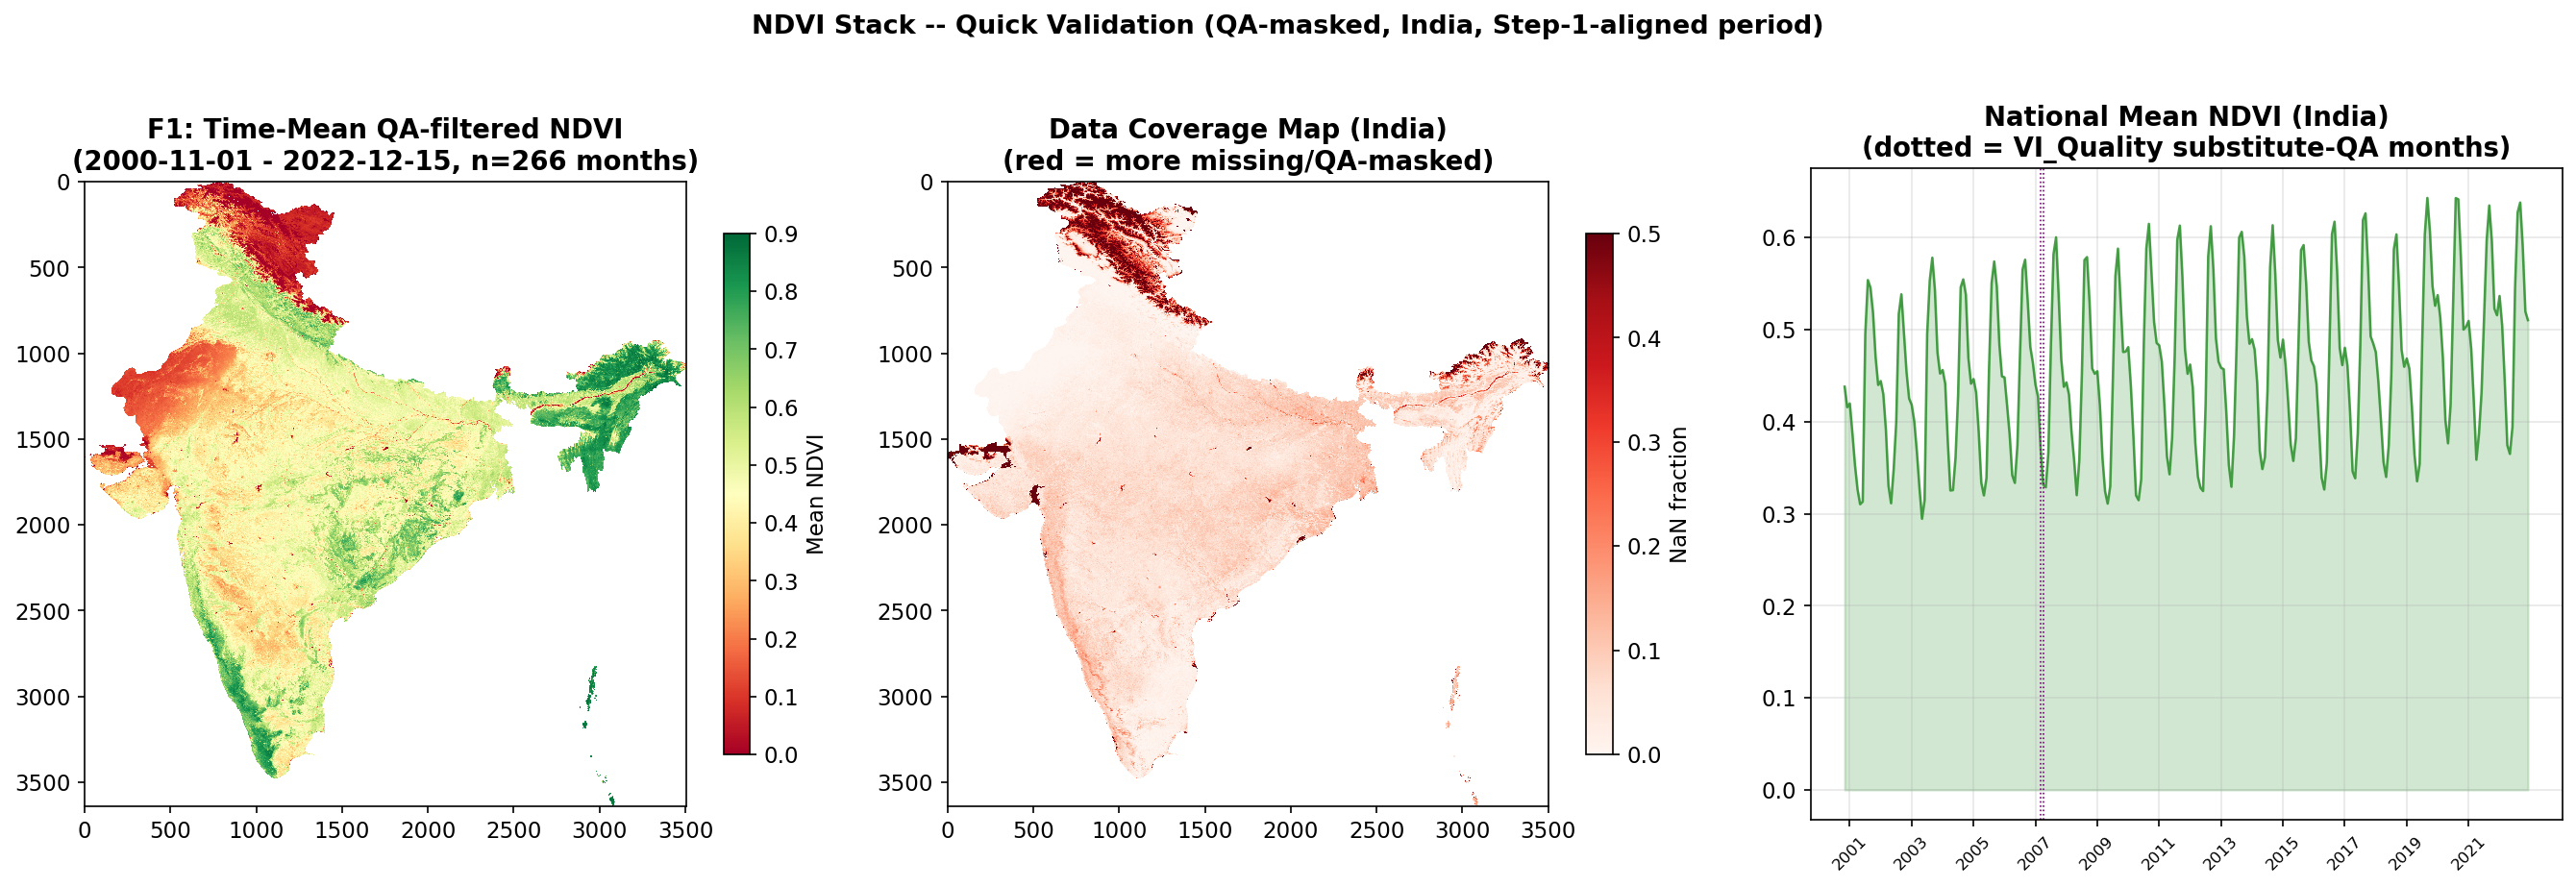

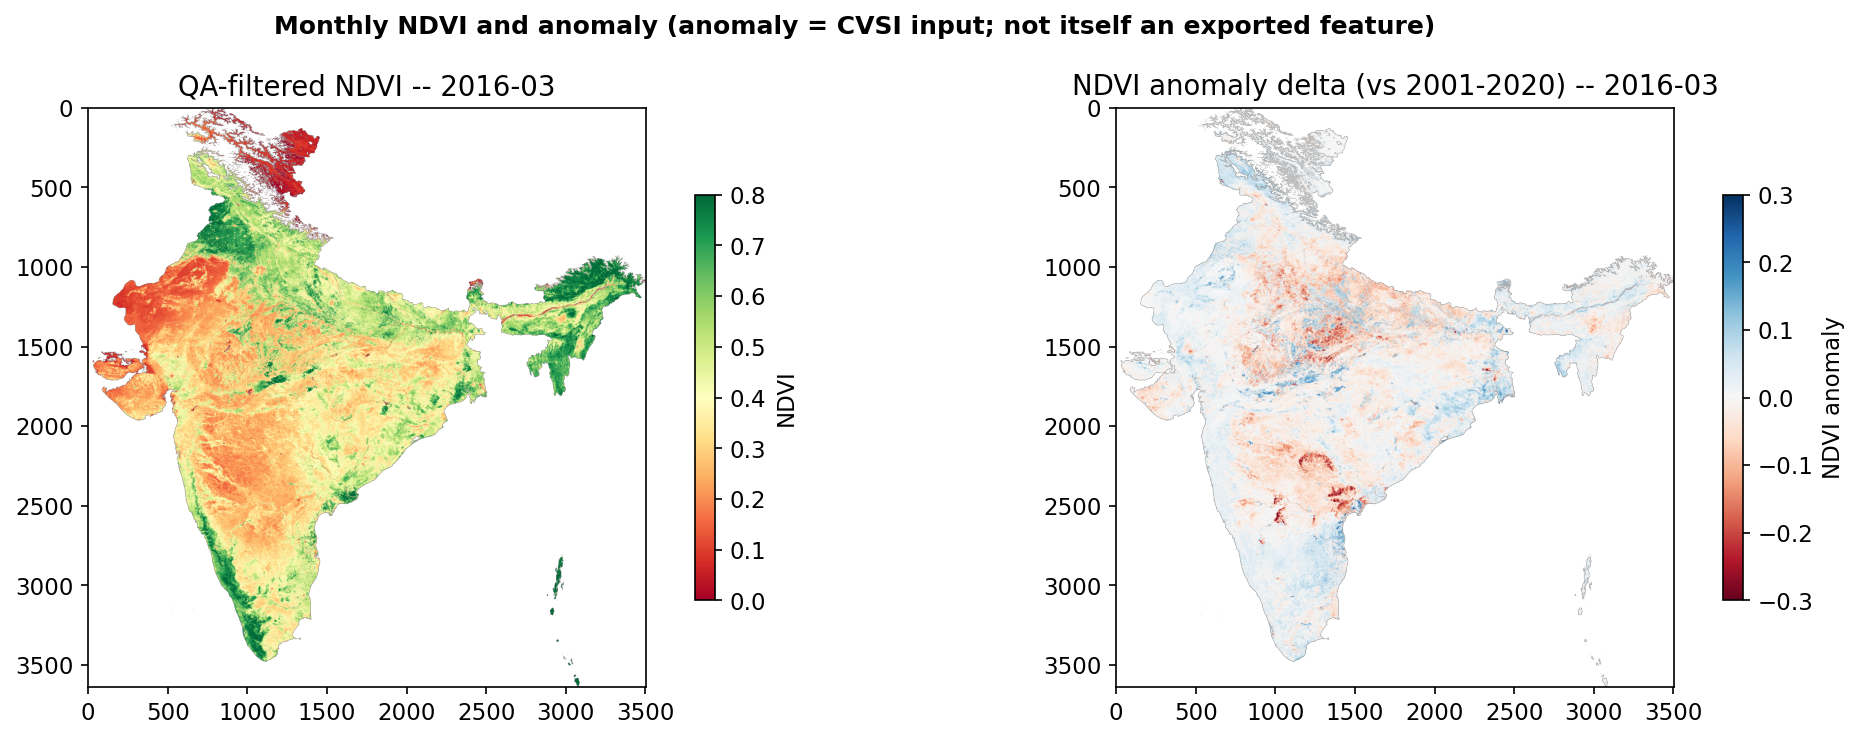

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
im0 = axes[0].imshow(F1_grid, cmap='RdYlGn', vmin=0.0, vmax=0.9, interpolation='nearest')
plt.colorbar(im0, ax=axes[0], label='Mean NDVI', shrink=0.8)
axes[0].set_title(f'F1: Time-Mean QA-filtered NDVI\n({STUDY_START.date()} - {STUDY_END.date()}, n={T} months)',
                  fontweight='bold')

nan_frac = to_grid(np.isnan(X).mean(axis=0))
im1 = axes[1].imshow(nan_frac, cmap='Reds', vmin=0, vmax=0.5, interpolation='nearest')
plt.colorbar(im1, ax=axes[1], label='NaN fraction', shrink=0.8)
axes[1].set_title('Data Coverage Map (India)\n(red = more missing/QA-masked)', fontweight='bold')

national_mean = np.nanmean(X, axis=1)
ax = axes[2]
ax.plot(range(T), national_mean, color='forestgreen', lw=1.2, alpha=0.8)
ax.fill_between(range(T), national_mean, alpha=0.2, color='forestgreen')
tick_pos  = [i for i, (y, m) in enumerate(year_month_list) if m == 1]
tick_labs = [str(y) for y, m in year_month_list if m == 1]
ax.set_xticks(tick_pos[::2]); ax.set_xticklabels(tick_labs[::2], rotation=45, fontsize=8)
for i, (qs, (y, m)) in enumerate(zip(qa_source, year_month_list)):
    if qs != 'pixel_reliability':
        ax.axvline(i, color='purple', lw=0.8, ls=':')
ax.set_title(f'National Mean NDVI (India)\n(dotted = VI_Quality substitute-QA months)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('NDVI Stack -- Quick Validation (QA-masked, India, Step-1-aligned period)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'validation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
del nan_frac

target = (2016, 3) if (2016, 3) in year_month_list else year_month_list[len(year_month_list)//2]
t_idx = year_month_list.index(target)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(to_grid(X[t_idx]), cmap='RdYlGn', vmin=0, vmax=0.8)
axes[0].set_title(f'QA-filtered NDVI -- {target[0]}-{target[1]:02d}')
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='NDVI')
im1 = axes[1].imshow(to_grid(ndvi_anomaly[t_idx]), cmap='RdBu', vmin=-0.3, vmax=0.3)
axes[1].set_title(f'NDVI anomaly delta (vs 2001-2020) -- {target[0]}-{target[1]:02d}')
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='NDVI anomaly')
plt.suptitle('Monthly NDVI and anomaly (anomaly = CVSI input; not itself an exported feature)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'NDVI_monthly_anomaly_example.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 6 -- F6 (v2): Seasonal Kendall trend test, BH-FDR and seasonal Sen slope (GPU)
**Why v1's F6 was replaced.** v1 ran Mann-Kendall on the 2x12 moving-average *trend* series. That
series is a 13-month running mean -- its median lag-1 autocorrelation is 0.975 -- so the MK
independence assumption fails and the p-values are invalid (audit, *Step 7 -- NDVI*).

**v2 (Hirsch, Slack & Smith 1982).** On the monthly **QA-filtered NDVI** (not the trend series):

* for each calendar month m, the Mann-Kendall statistic S_m over the years (all within-month
  pairs, NaN-aware), with tie-corrected variance Var(S_m) = [n(n-1)(2n+5) - sum_t t(t-1)(2t+5)] / 18;
* S = sum_m S_m, Var(S) = sum_m Var(S_m); tau_SK = S / sum_m C(n_m, 2);
* z with continuity correction, two-sided p = erfc(|z|/sqrt 2), computed only where >= 30
  within-month pairs exist;
* Benjamini-Hochberg (1995) q-values over all in-India pixels with a p-value;
* seasonal Sen slope = median of all within-calendar-month pairwise slopes (NDVI / yr).

Comparing each month only with the same calendar month removes the seasonal cycle; pairs one or
more years apart are far less serially dependent than the running-mean series (median lag-1
autocorrelation of the monthly anomaly: 0.475, audit). Vectorised on the GPU over pixel chunks
(the within-month lag sweep is algebraically identical to the full pairwise sum); the implementation
is a port of the audit's unit-tested `trend_stats.seasonal_kendall / seasonal_sen / bh_fdr`.

Seasonal Sen: 2,816 within-month pairs per pixel
Computing Seasonal Kendall + seasonal Sen slope (GPU)...


Seasonal Kendall / Sen (pixel chunks):   0%|          | 0/42 [00:00<?, ?it/s]

Seasonal Kendall / Sen (pixel chunks):   2%|▏         | 1/42 [00:02<01:24,  2.06s/it]

Seasonal Kendall / Sen (pixel chunks):   5%|▍         | 2/42 [00:02<00:43,  1.10s/it]

Seasonal Kendall / Sen (pixel chunks):   7%|▋         | 3/42 [00:02<00:30,  1.29it/s]

...

Seasonal Kendall / Sen (pixel chunks):  95%|█████████▌| 40/42 [00:18<00:00,  2.40it/s]

Seasonal Kendall / Sen (pixel chunks):  98%|█████████▊| 41/42 [00:18<00:00,  2.36it/s]

Seasonal Kendall / Sen (pixel chunks): 100%|██████████| 42/42 [00:19<00:00,  2.11it/s]

Seasonal Kendall / Sen (pixel chunks): 100%|██████████| 42/42 [00:19<00:00,  2.17it/s]

  Pixels with a p-value (>= 30 within-month pairs): 4,153,368
  Raw p < 0.05                        : 3,641,791
  BH-FDR q < 0.05: greening (tau>0) : 3,552,278   (audit: 3,552,278)
  BH-FDR q < 0.05: browning (tau<0) : 72,305   (audit: 72,305)
  Median seasonal Sen slope           : +0.00262 NDVI/yr   (audit: +0.00262)


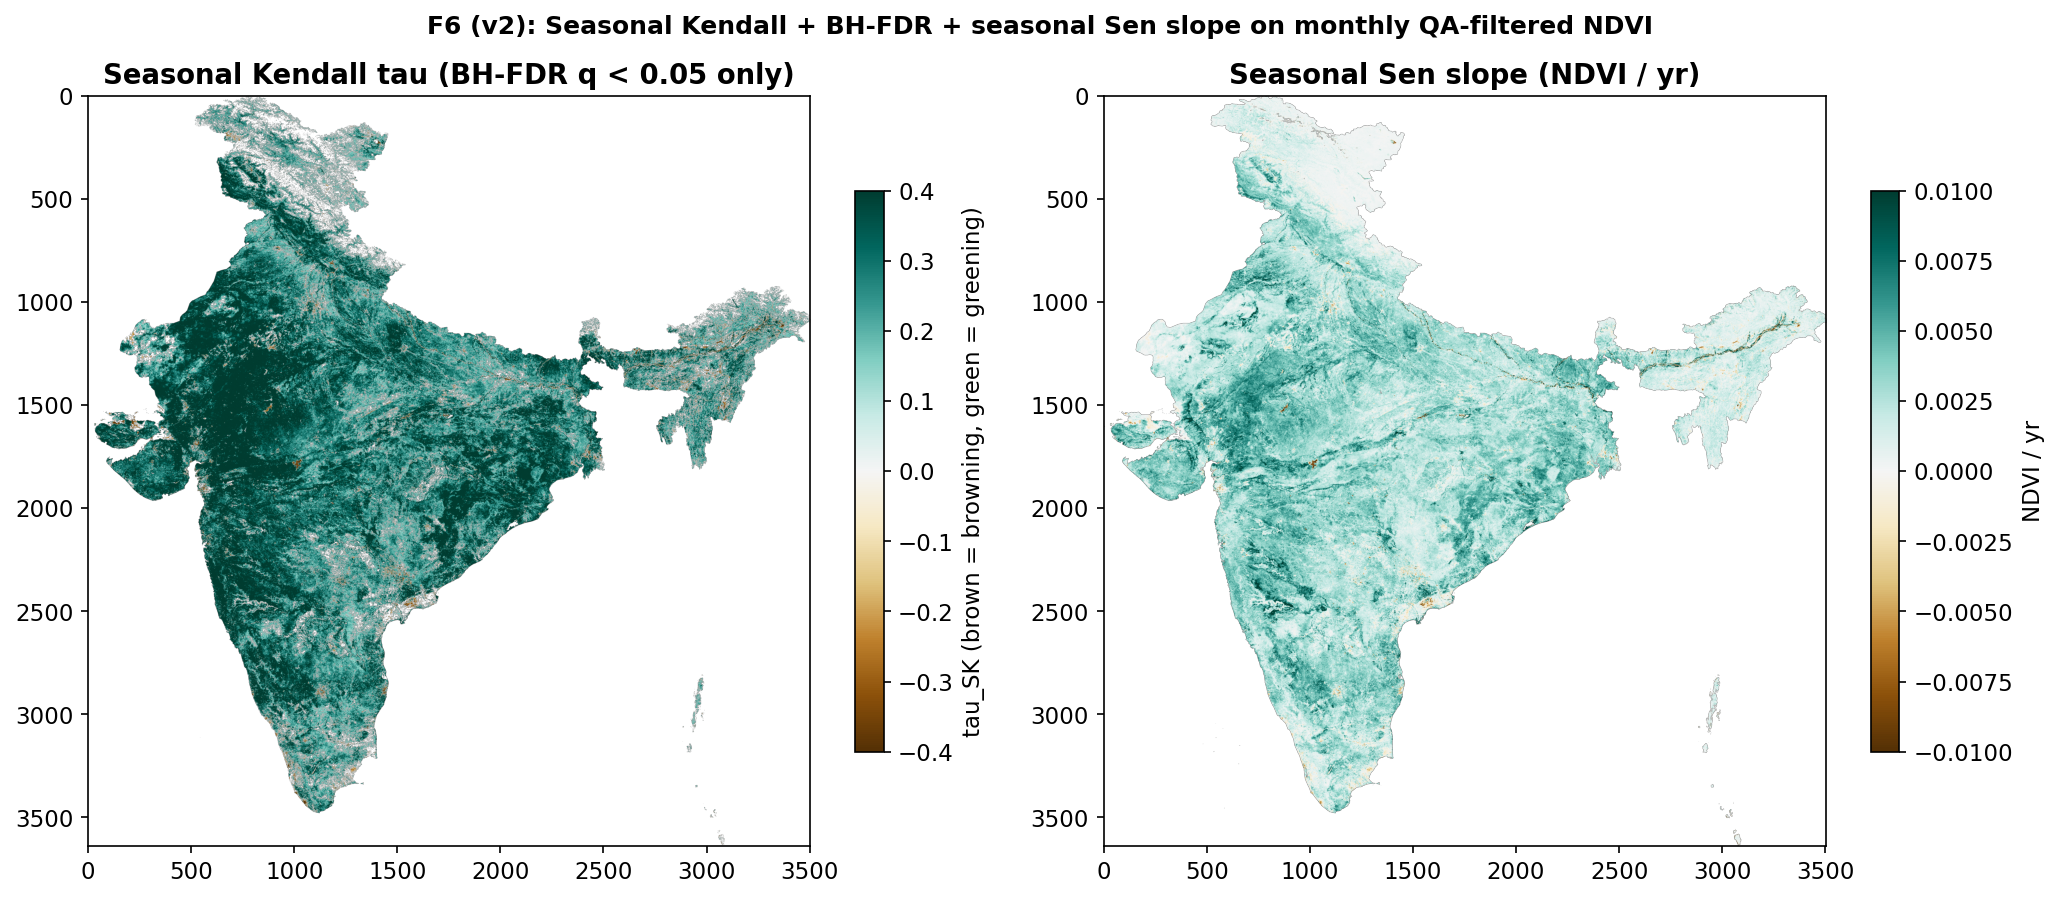

In [9]:
# CuPy/NumPy sort must place NaN last (median and tie-run logic rely on it) -- check, don't assume.
_chk = to_host(cp.sort(cp.asarray(np.array([[np.nan], [1.0], [0.0]])), axis=0)).ravel()
assert _chk[0] == 0.0 and _chk[1] == 1.0 and np.isnan(_chk[2]), f"unexpected NaN sort order: {_chk}"


def _tie_term(xm):
    # Sum over tie groups of t(t-1)(2t+5) per column; xm (Y, n) with NaNs.
    xs = cp.sort(xm, axis=0)
    eq = (xs[1:] == xs[:-1]) & ~cp.isnan(xs[1:])
    out = cp.zeros(xm.shape[1], dtype=cp.float64)
    run = cp.zeros(xm.shape[1], dtype=cp.float64)
    for k in range(eq.shape[0]):
        e_k = eq[k]
        run = cp.where(e_k, run + 1, run)
        t = run + 1
        out += cp.where(~e_k & (run > 0), t * (t - 1) * (2 * t + 5), 0.0)
        run = cp.where(~e_k, 0.0, run)
    t = run + 1
    out += cp.where(run > 0, t * (t - 1) * (2 * t + 5), 0.0)
    return out


def seasonal_kendall_xp(Xc, months):
    # Xc: (T, n) monthly series on device; months: (T,) calendar month 1..12 (host).
    n = Xc.shape[1]
    S = cp.zeros(n, dtype=cp.float64); V = cp.zeros(n, dtype=cp.float64); NP = cp.zeros(n, dtype=cp.float64)
    for m in range(1, 13):
        rows = np.flatnonzero(months == m)
        if rows.size < 2:
            continue
        xm = Xc[cp.asarray(rows)]
        Sm = cp.zeros(n, dtype=cp.float64)
        for lag in range(1, xm.shape[0]):
            Sm += cp.nansum(cp.sign(xm[lag:] - xm[:-lag]), axis=0)
        nm = cp.sum(~cp.isnan(xm), axis=0).astype(cp.float64)
        Vm = (nm * (nm - 1) * (2 * nm + 5) - _tie_term(xm)) / 18.0
        ok = nm >= 2
        S += Sm
        V += cp.where(ok, Vm, 0.0)
        NP += cp.where(ok, nm * (nm - 1) / 2.0, 0.0)
    sq = cp.sqrt(cp.maximum(V, 1e-12))
    z = cp.where(S > 0, (S - 1) / sq, cp.where(S < 0, (S + 1) / sq, 0.0))
    tau = cp.where(NP > 0, S / cp.where(NP > 0, NP, 1.0), cp.nan)
    p = cp.where(NP >= SK_MIN_PAIRS, erfc_fn(cp.abs(z) / np.sqrt(2.0)), cp.nan)
    return S, tau, z, p, NP


def nanmedian_axis0(a):
    # NaN-aware median along axis 0 (sort-based; identical to np.nanmedian, fast on GPU and CPU).
    s = cp.sort(a, axis=0)
    n = cp.sum(~cp.isnan(a), axis=0)
    lo = cp.maximum((n - 1) // 2, 0)
    hi = cp.maximum(n // 2, 0)
    v_lo = cp.take_along_axis(s, lo[None, :], axis=0)[0]
    v_hi = cp.take_along_axis(s, hi[None, :], axis=0)[0]
    return cp.where(n > 0, 0.5 * (v_lo + v_hi), cp.nan)


# All within-calendar-month (i < j) pairs, fixed for the whole grid
_pi, _pj = [], []
for m in range(1, 13):
    rows = np.flatnonzero(months_arr == m)
    for a_i in range(rows.size):
        for b_i in range(a_i + 1, rows.size):
            _pi.append(rows[a_i]); _pj.append(rows[b_i])
pair_i = np.array(_pi); pair_j = np.array(_pj)
pair_dy = (years_arr[pair_j] - years_arr[pair_i]).astype(np.float64)
pair_i_dev, pair_j_dev, pair_dy_dev = cp.asarray(pair_i), cp.asarray(pair_j), cp.asarray(pair_dy)
print(f"Seasonal Sen: {pair_i.size:,} within-month pairs per pixel")


def seasonal_sen_xp(Xc):
    sl = Xc[pair_j_dev].astype(cp.float64)
    sl -= Xc[pair_i_dev]
    sl /= pair_dy_dev[:, None]
    return nanmedian_axis0(sl)


def bh_fdr(p):
    # Benjamini-Hochberg (1995) q-values for a 1-D array with NaNs (NaN stays NaN).
    q = np.full(p.shape, np.nan)
    ok = np.isfinite(p)
    pv = p[ok]
    n = pv.size
    if n == 0:
        return q
    o = np.argsort(pv)
    ranked = pv[o] * n / np.arange(1, n + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    qq = np.empty(n); qq[o] = np.minimum(ranked, 1.0)
    q[ok] = qq
    return q


print("Computing Seasonal Kendall + seasonal Sen slope " + ("(GPU)..." if GPU_AVAILABLE else "(CPU)..."))
sk_tau = np.full(N_IN, np.nan); sk_p = np.full(N_IN, np.nan)
sk_np = np.zeros(N_IN); sen_slope = np.full(N_IN, np.nan)
X_dev = cp.asarray(X)
for s0 in tqdm(range(0, N_IN, TREND_CHUNK), desc="Seasonal Kendall / Sen (pixel chunks)"):
    s1 = min(s0 + TREND_CHUNK, N_IN)
    Xc = X_dev[:, s0:s1]
    _, tau_c, _, p_c, np_c = seasonal_kendall_xp(Xc, months_arr)
    sk_tau[s0:s1] = to_host(tau_c); sk_p[s0:s1] = to_host(p_c); sk_np[s0:s1] = to_host(np_c)
    sen_slope[s0:s1] = to_host(seasonal_sen_xp(Xc))
    del Xc, tau_c, p_c, np_c
    free_gpu()
del X_dev, pair_i_dev, pair_j_dev, pair_dy_dev
free_gpu()

sk_q = bh_fdr(sk_p)
sig = sk_q < FDR_ALPHA
sk_stats = dict(
    n_with_pvalue=int(np.isfinite(sk_p).sum()),
    n_tau_defined_but_lt_min_pairs=int((np.isfinite(sk_tau) & ~np.isfinite(sk_p)).sum()),
    sig_p05_total=int(np.nansum(sk_p < 0.05)),
    sig_fdr_greening=int(np.sum(sig & (sk_tau > 0))),
    sig_fdr_browning=int(np.sum(sig & (sk_tau < 0))),
    sen_median_per_yr=float(np.nanmedian(sen_slope)),
    tau_median=float(np.nanmedian(sk_tau)),
)
print(f"  Pixels with a p-value (>= {SK_MIN_PAIRS} within-month pairs): {sk_stats['n_with_pvalue']:,}")
print(f"  Raw p < 0.05                        : {sk_stats['sig_p05_total']:,}")
print(f"  BH-FDR q < {FDR_ALPHA}: greening (tau>0) : {sk_stats['sig_fdr_greening']:,}   (audit: 3,552,278)")
print(f"  BH-FDR q < {FDR_ALPHA}: browning (tau<0) : {sk_stats['sig_fdr_browning']:,}   (audit: 72,305)")
print(f"  Median seasonal Sen slope           : {sk_stats['sen_median_per_yr']:+.5f} NDVI/yr   (audit: +0.00262)")
RUN_SUMMARY['F6_seasonal_kendall'] = sk_stats

F6_tau_grid = to_grid(sk_tau)
F6_q_grid = to_grid(sk_q)
F6_sen_grid = to_grid(sen_slope)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(np.where(F6_q_grid < FDR_ALPHA, F6_tau_grid, np.nan), cmap='BrBG', vmin=-0.4, vmax=0.4)
axes[0].set_title(f'Seasonal Kendall tau (BH-FDR q < {FDR_ALPHA} only)', fontweight='bold')
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='tau_SK (brown = browning, green = greening)')
im1 = axes[1].imshow(F6_sen_grid, cmap='BrBG', vmin=-0.01, vmax=0.01)
axes[1].set_title('Seasonal Sen slope (NDVI / yr)', fontweight='bold')
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='NDVI / yr')
plt.suptitle('F6 (v2): Seasonal Kendall + BH-FDR + seasonal Sen slope on monthly QA-filtered NDVI',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'F6_SeasonalKendall_Sen.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 7 -- Rasterise Step 1's Real Fire Points onto the NDVI Grid (containing pixel)
Every one of Step 1's 541,545 points is mapped by exact affine inversion to the pixel whose
footprint **contains** it: with `c, f` = the top-left **edge** of the grid (`transform.c`,
`transform.f`) and `a, e` the pixel size,

`col = floor((lon - c) / a)`, `row = floor((lat - f) / e)`.

**v2 correction:** v1 used `round(...)` against the same *edge* origin, which is the containing
pixel only for points in one quadrant of each pixel -- 74.9% of points landed in a neighbouring pixel
(270,655 fire pixels, Jaccard 0.50 against the correct 268,766). This rule is used for F10, the
CVSI mutual-information labels (F7) and the breakpoint diagnostic.

Rasterizing Step 1 forest-fire points onto the NDVI grid (containing pixel, floor)...
  Fire points loaded (Step 1 output): 541,545


  In NDVI grid bounds: 541,545  (excluded 0 outside the raster extent)
  Points the v1 round-on-edge rule placed in a neighbouring pixel: 74.9%  (audit: 74.9%)
  With a matching NDVI month in 2000-11-01-2022-12-15: 541,545
  Sum of raster                : 541,545  (expected 541,545)
  Fire pixels, full grid       : 268,766  (expected 268,766)
  Fire pixels, India mask      : 268,476
  Fire pixels, NDVI-valid      : 268,411  (expected 268,411)
  Points whose pixel is outside the India mask: 412


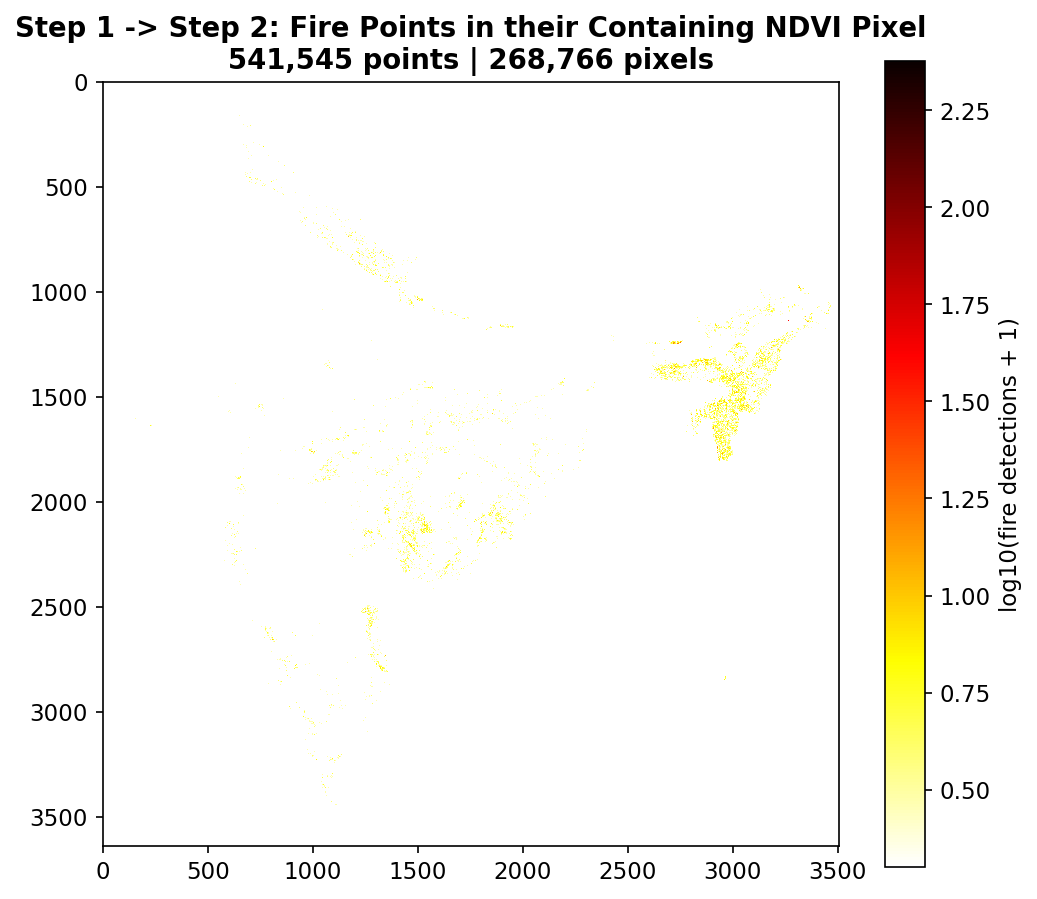

[OK] Fire rasterization complete -- drives F10, the F7 MI labels and the breakpoint diagnostic


In [10]:
print("Rasterizing Step 1 forest-fire points onto the NDVI grid (containing pixel, floor)...")
fire_df = pd.read_csv(FIRE_CSV, usecols=["latitude", "longitude", "acq_date", "year", "month"])
print(f"  Fire points loaded (Step 1 output): {len(fire_df):,}")

a, b, c, d, e, f = transform_ref[:6]   # affine coeffs; north-up grid so b=d=0; (c, f) = top-left EDGE
lat_v = fire_df["latitude"].values; lon_v = fire_df["longitude"].values
fire_row = np.floor((lat_v - f) / e).astype(np.int64)
fire_col = np.floor((lon_v - c) / a).astype(np.int64)

# Documentation of the v1 error: how many points the old round-on-edge rule displaced
_old_row = np.round((lat_v - f) / e).astype(np.int64); _old_col = np.round((lon_v - c) / a).astype(np.int64)
frac_displaced_v1 = float(np.mean((_old_row != fire_row) | (_old_col != fire_col)))
del _old_row, _old_col

in_bounds = (fire_row >= 0) & (fire_row < H) & (fire_col >= 0) & (fire_col < W)
n_out = int((~in_bounds).sum())
fire_row, fire_col = fire_row[in_bounds], fire_col[in_bounds]
fire_year  = fire_df["year"].values[in_bounds]
fire_month = fire_df["month"].values[in_bounds]
print(f"  In NDVI grid bounds: {in_bounds.sum():,}  (excluded {n_out:,} outside the raster extent)")
print(f"  Points the v1 round-on-edge rule placed in a neighbouring pixel: {100*frac_displaced_v1:.1f}%  (audit: 74.9%)")

ym_index = {ym: i for i, ym in enumerate(year_month_list)}
fire_t = np.array([ym_index.get((y, m), -1) for y, m in zip(fire_year, fire_month)])
print(f"  With a matching NDVI month in {STUDY_START.date()}-{STUDY_END.date()}: {(fire_t >= 0).sum():,}")

fire_count_map = np.zeros((H, W), dtype=np.int32)
np.add.at(fire_count_map, (fire_row, fire_col), 1)
fire_ever_mask = fire_count_map > 0

# In-India pixel position of each point (-1 if its containing pixel is outside the India mask)
pos_of = np.full(H * W, -1, dtype=np.int64); pos_of[india_idx] = np.arange(N_IN)
fire_pix = pos_of[fire_row * W + fire_col]
fire_ever_in = fire_count_map.ravel()[india_idx] > 0          # per in-India pixel

fire_stats = dict(
    n_points=int(len(fire_df)), n_points_in_grid=int(in_bounds.sum()),
    n_points_sum_raster=int(fire_count_map.sum()),
    fire_pixels_full_grid=int(fire_ever_mask.sum()),
    fire_pixels_india_mask=int(fire_ever_in.sum()),
    fire_pixels_ndvi_valid=int((fire_ever_in & valid_px).sum()),
    n_points_outside_india_mask=int((fire_pix < 0).sum()),
    frac_points_displaced_by_v1_rule=frac_displaced_v1,
)
print(f"  Sum of raster                : {fire_stats['n_points_sum_raster']:,}  (expected 541,545)")
print(f"  Fire pixels, full grid       : {fire_stats['fire_pixels_full_grid']:,}  (expected 268,766)")
print(f"  Fire pixels, India mask      : {fire_stats['fire_pixels_india_mask']:,}")
print(f"  Fire pixels, NDVI-valid      : {fire_stats['fire_pixels_ndvi_valid']:,}  (expected 268,411)")
print(f"  Points whose pixel is outside the India mask: {fire_stats['n_points_outside_india_mask']:,}")
RUN_SUMMARY['fire_rasterisation'] = fire_stats

np.save(OUT_DIR / 'fire_count_map.npy', fire_count_map)

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(np.where(fire_count_map > 0, np.log10(fire_count_map + 1), np.nan),
               cmap='hot_r', interpolation='nearest')
plt.colorbar(im, ax=ax, label='log10(fire detections + 1)', shrink=0.7)
ax.set_title(f'Step 1 -> Step 2: Fire Points in their Containing NDVI Pixel\n'
             f'{len(fire_df):,} points | {fire_stats["fire_pixels_full_grid"]:,} pixels', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'F10_fire_raster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Fire rasterization complete -- drives F10, the F7 MI labels and the breakpoint diagnostic')


## Step 8 -- F7: CVSI with a Real, Data-Driven Optimal Lag k\*
CVSI(t, k) = sum_{lag=1..k} max(-delta_{t-lag}, 0) -- the accumulated pre-fire NDVI deficit over the
k months *before* t (trailing, excludes month t), anomaly delta vs the 2001-2020 climatology; defined
where at least max(1, k//2) of the k lags are valid. The exported feature is the time mean of
CVSI(t, k\*) (definition unchanged from v1).

**k\* is fitted on real fire labels, not assumed.** For each k = 1..12, the mutual information
between binned CVSI and fire occurrence is computed with

* positives: every Step 1 fire point (containing pixel, v2 rule) in an in-India pixel, at its own
  month t >= k (one entry per point, so repeated detections weigh as in the data);
* negatives: random pixel-months (t >= k) drawn from never-burned, NDVI-valid in-India pixels,
  n_neg = n_pos;
* 10 quantile bins (exact quantiles), `sklearn.metrics.mutual_info_score`;
* averaged over 5 independent background draws (seeds 42-46); k\* = argmax of the mean MI.

The full table (mean, SD, per-seed values) is written to `F7_CVSI_MI_lag_sweep.csv`.
Note for the manuscript: k\* uses all fire labels, including pixels that later fall in a test
partition; the audit repeated the sweep on training-partition labels only and obtained the same
k\* = 8, so the selected lag is not an artefact of test-label exposure.

Selecting optimal CVSI lag k via mutual information with real Step 1 fire occurrence...
  Negative pool: 3,892,357 never-burned NDVI-valid India pixels


  k= 1: n_fire=540,823  n_bg=540,823  MI = 0.00189 +/- 0.00005


  k= 2: n_fire=540,745  n_bg=540,745  MI = 0.00057 +/- 0.00002


  k= 3: n_fire=540,507  n_bg=540,507  MI = 0.00083 +/- 0.00003


  k= 4: n_fire=539,210  n_bg=539,210  MI = 0.00308 +/- 0.00005


...

  k= 8: n_fire=534,949  n_bg=534,949  MI = 0.01230 +/- 0.00017


  k= 9: n_fire=534,954  n_bg=534,954  MI = 0.01036 +/- 0.00015


  k=10: n_fire=534,934  n_bg=534,934  MI = 0.00926 +/- 0.00008


  k=11: n_fire=534,938  n_bg=534,938  MI = 0.00838 +/- 0.00008


  k=12: n_fire=534,925  n_bg=534,925  MI = 0.00754 +/- 0.00008

* Optimal lag k* = 8 months (mean MI over 5 background draws; audit: 8)
  MI(k*) = 0.01230 +/- 0.00017;  runner-up k=7: 0.01114 +/- 0.00007
  MI table -> D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs\F7_CVSI_MI_lag_sweep.csv


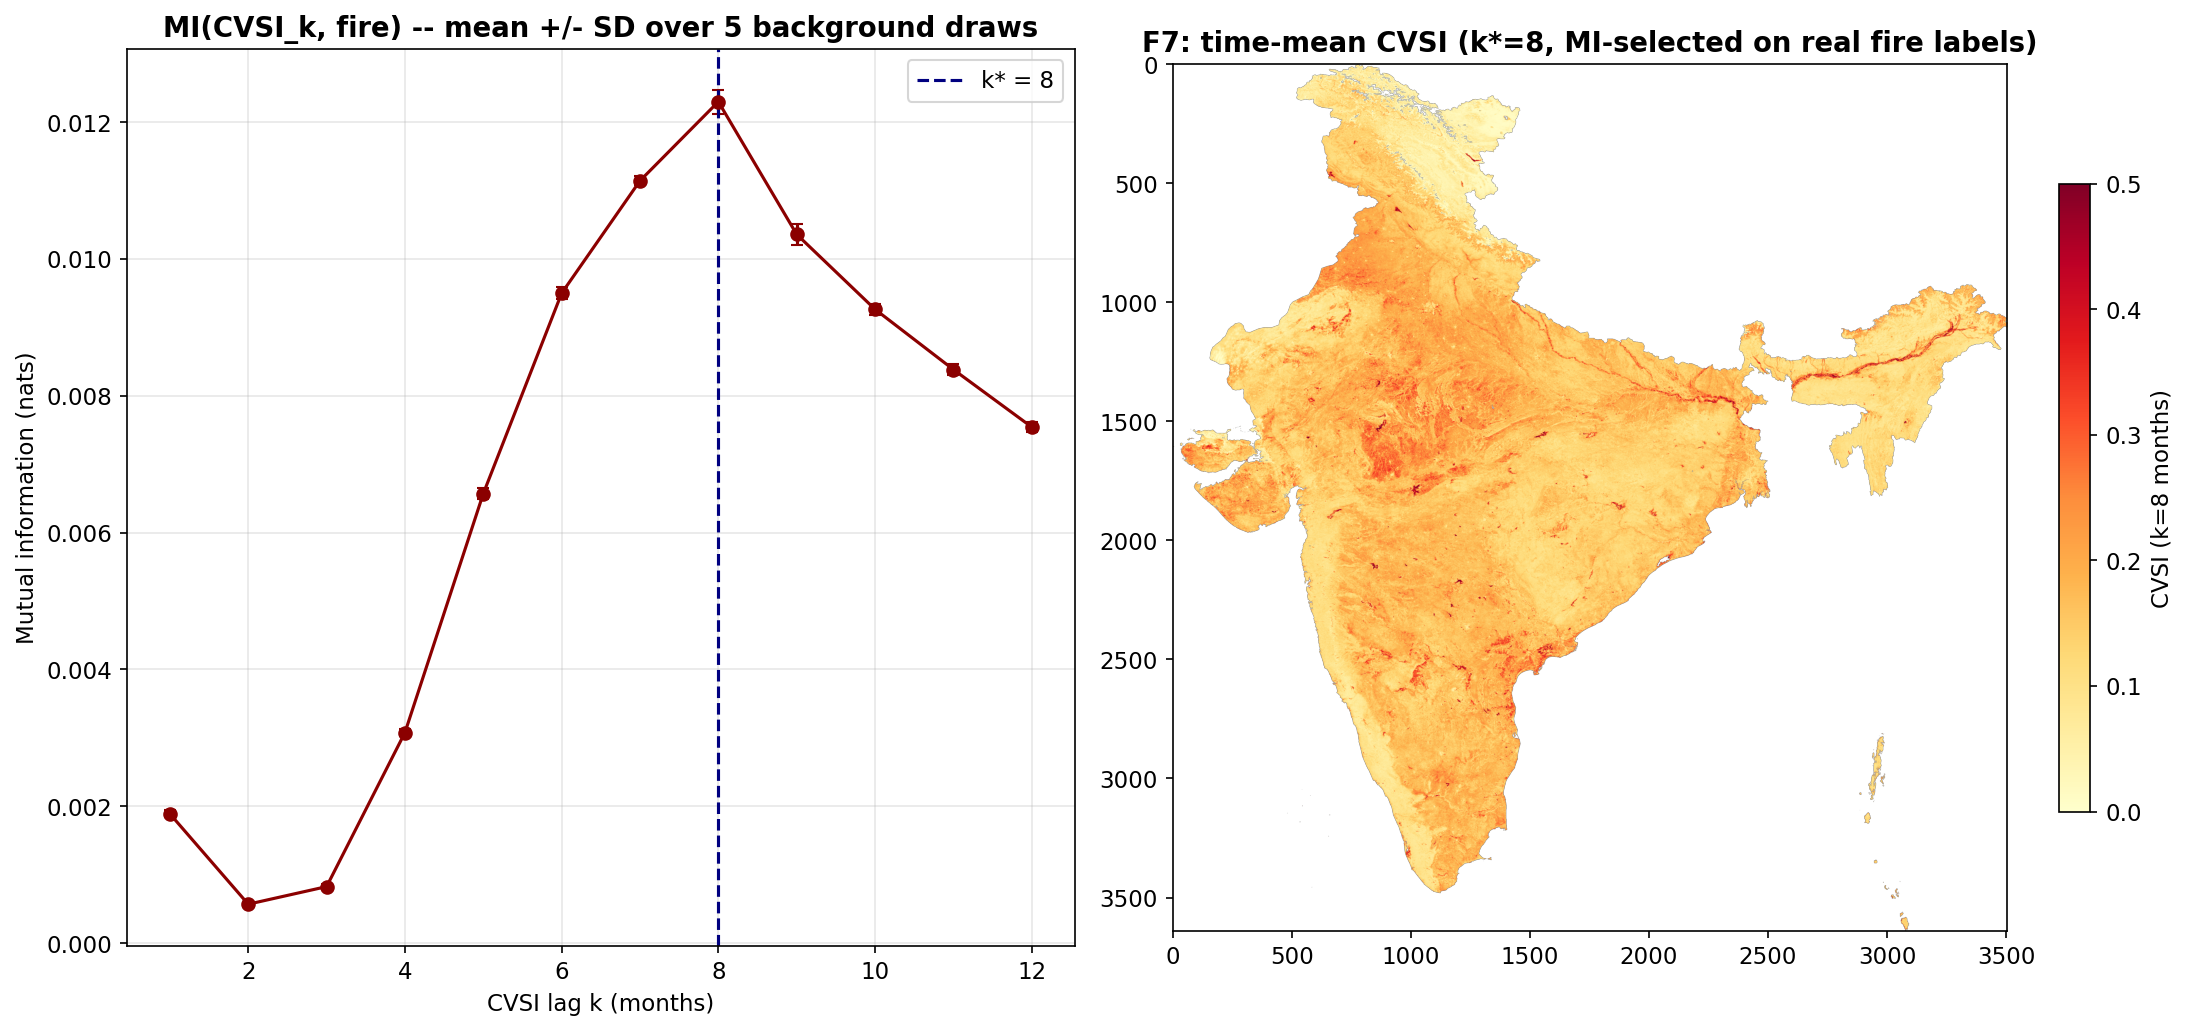

[OK] CVSI complete (k*=8)


In [11]:
def compute_cvsi(anom_dev, k):
    # anom_dev: (T, n) anomaly on device. Returns CVSI(t, k), NaN for t < k or too few valid lags.
    T_, n_ = anom_dev.shape
    cv = cp.full((T_, n_), cp.nan, dtype=cp.float32)
    need = max(1, k // 2)
    for t in range(k, T_):
        win = anom_dev[t - k:t]
        stress = cp.where(win < 0, -win, 0.0)          # NaN < 0 is False -> contributes 0
        nv = cp.sum(~cp.isnan(win), axis=0)
        cv[t] = cp.where(nv >= need, stress.sum(axis=0), cp.nan)
    return cv


def nanmean_axis0(a):
    cnt = cp.sum(~cp.isnan(a), axis=0)
    tot = cp.nansum(a, axis=0)
    return cp.where(cnt > 0, tot / cp.maximum(cnt, 1), cp.nan)


def quantile_bins(x, n_bins=MI_N_BINS):
    kw = dict(n_bins=n_bins, encode='ordinal', strategy='quantile')
    params = inspect.signature(KBinsDiscretizer).parameters
    if 'subsample' in params:
        kw['subsample'] = None                 # exact quantiles -> deterministic bins
    if 'quantile_method' in params:
        kw['quantile_method'] = 'linear'       # pin current default (sklearn >= 1.7 warns it will change)
    return KBinsDiscretizer(**kw).fit_transform(x.reshape(-1, 1)).ravel()


print("Selecting optimal CVSI lag k via mutual information with real Step 1 fire occurrence...")
neg_pool = np.flatnonzero(~fire_ever_in & valid_px)      # never-burned, NDVI-valid in-India pixels
print(f"  Negative pool: {neg_pool.size:,} never-burned NDVI-valid India pixels")

anom_dev = cp.asarray(ndvi_anomaly)
mi_rows, cvsi_mean_by_k = [], {}
for k in CVSI_K_RANGE:
    cv_dev = compute_cvsi(anom_dev, k)
    sel = (fire_pix >= 0) & (fire_t >= k)
    pos_vals = to_host(cv_dev[cp.asarray(fire_t[sel]), cp.asarray(fire_pix[sel])])
    pos_vals = pos_vals[np.isfinite(pos_vals)]
    n_pos = pos_vals.size
    per_seed, n_negs = [], []
    for seed in MI_SEEDS:
        rng = np.random.RandomState(seed)
        pp = rng.choice(neg_pool, size=n_pos * 3, replace=True)     # oversample, keep first n_pos finite
        tt = rng.randint(k, T, size=pp.size)
        neg_vals = to_host(cv_dev[cp.asarray(tt), cp.asarray(pp)])
        neg_vals = neg_vals[np.isfinite(neg_vals)][:n_pos]
        x = np.concatenate([pos_vals, neg_vals])
        y = np.concatenate([np.ones(n_pos), np.zeros(neg_vals.size)])
        per_seed.append(float(mutual_info_score(y, quantile_bins(x))))
        n_negs.append(int(neg_vals.size))
    cvsi_mean_by_k[k] = to_host(nanmean_axis0(cv_dev)).astype(np.float32)
    del cv_dev
    free_gpu()
    row = dict(k=k, mi_mean=float(np.mean(per_seed)), mi_sd=float(np.std(per_seed, ddof=1)),
               n_pos=int(n_pos), n_neg_min=int(min(n_negs)))
    row.update({f'mi_seed{s}': v for s, v in zip(MI_SEEDS, per_seed)})
    mi_rows.append(row)
    print(f"  k={k:2d}: n_fire={n_pos:,}  n_bg={min(n_negs):,}  MI = {row['mi_mean']:.5f} +/- {row['mi_sd']:.5f}")
del anom_dev
free_gpu()

mi_table = pd.DataFrame(mi_rows)
k_star = int(mi_table.loc[mi_table['mi_mean'].idxmax(), 'k'])
mi_table['is_k_star'] = mi_table['k'] == k_star
mi_table.to_csv(OUT_DIR / 'F7_CVSI_MI_lag_sweep.csv', index=False)
_best = mi_table.set_index('k')
_runner = _best.drop(index=k_star)['mi_mean'].idxmax()
print(f"\n* Optimal lag k* = {k_star} months (mean MI over {len(MI_SEEDS)} background draws; audit: 8)")
print(f"  MI(k*) = {_best.loc[k_star, 'mi_mean']:.5f} +/- {_best.loc[k_star, 'mi_sd']:.5f};  "
      f"runner-up k={_runner}: {_best.loc[_runner, 'mi_mean']:.5f} +/- {_best.loc[_runner, 'mi_sd']:.5f}")
print(f"  MI table -> {OUT_DIR / 'F7_CVSI_MI_lag_sweep.csv'}")

F7_vec = cvsi_mean_by_k[k_star]
F7_grid = to_grid(F7_vec)
RUN_SUMMARY['F7_cvsi'] = dict(k_star=k_star, mi_table=mi_rows,
                             F7_valid_pixels=int(np.isfinite(F7_vec).sum()))

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [1, 1.1]})
axes[0].errorbar(mi_table['k'], mi_table['mi_mean'], yerr=mi_table['mi_sd'], marker='o', capsize=3, color='darkred')
axes[0].axvline(k_star, color='navy', ls='--', label=f'k* = {k_star}')
axes[0].set_xlabel('CVSI lag k (months)'); axes[0].set_ylabel('Mutual information (nats)')
axes[0].set_title('MI(CVSI_k, fire) -- mean +/- SD over 5 background draws', fontweight='bold')
axes[0].grid(True, alpha=0.3); axes[0].legend()
im = axes[1].imshow(F7_grid, cmap='YlOrRd', vmin=0, vmax=0.5)
plt.colorbar(im, ax=axes[1], label=f'CVSI (k={k_star} months)', shrink=0.7)
axes[1].set_title(f'F7: time-mean CVSI (k*={k_star}, MI-selected on real fire labels)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'F7_CVSI_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] CVSI complete (k*={k_star})')


## Step 9 -- F8 (v2): Global Moran's I + Local LISA on India-only 8 km block means
**v1 problem:** F1 was *subsampled* every 8th pixel, and the 67% of lattice cells outside India
(ocean, neighbouring countries) were filled with row means before computing Moran's I -- so the
statistic partly described artificial fill values (I = 0.8322).

**v2:**
1. 8x8 **block means** of F1 (NaN-aware) -> 8 km cells (`H//8 x W//8`);
2. keep only cells with a valid (in-India) value; queen-contiguity lattice `lat2W(rook=False)`
   restricted to those cells with `libpysal.weights.w_subset`, row-standardised -- no fill values;
3. global Moran's I with 999 permutations (I, z_sim, p_sim reported; audit: I = 0.9456);
4. Local Moran's I (199 permutations, seed 42) on **float64** input (esda's Numba kernels fail on
   float32); cluster code = quadrant q (1 HH, 2 LH, 3 LL, 4 HL) where p_sim < 0.05, else 0;
5. blocks upsampled x8 back to the 1 km grid; NaN outside India.

Computing spatial autocorrelation on 8x8 block means of F1 (455 x 438 blocks)...
  Valid (India) blocks: 66,703 of 199,290  (no fill values used)


  Weights: queen lattice subset, n=66,703, islands=7, row-standardised



-- Global Moran's I (India-only block means) --
  I       = 0.9456   (audit: 0.9456; E[I] = -1.50e-05)
  z_sim   = 479.76
  p_sim   = 0.0010  (999 permutations)

Computing Local Moran's I (LISA, 199 permutations, seed 42)...



-- LISA cluster counts (p_sim < 0.05, blocks) --
  Not Significant                              :  40,601  (60.9%)
  High-High (HH): Dense vegetation cluster     :  14,185  (21.3%)
  Low-High (LH): Sparse in dense neighbourhood :      40  (0.1%)
  Low-Low (LL): Sparse/degraded vegetation     :  11,853  (17.8%)
  High-Low (HL): Vegetation fragment           :      24  (0.0%)


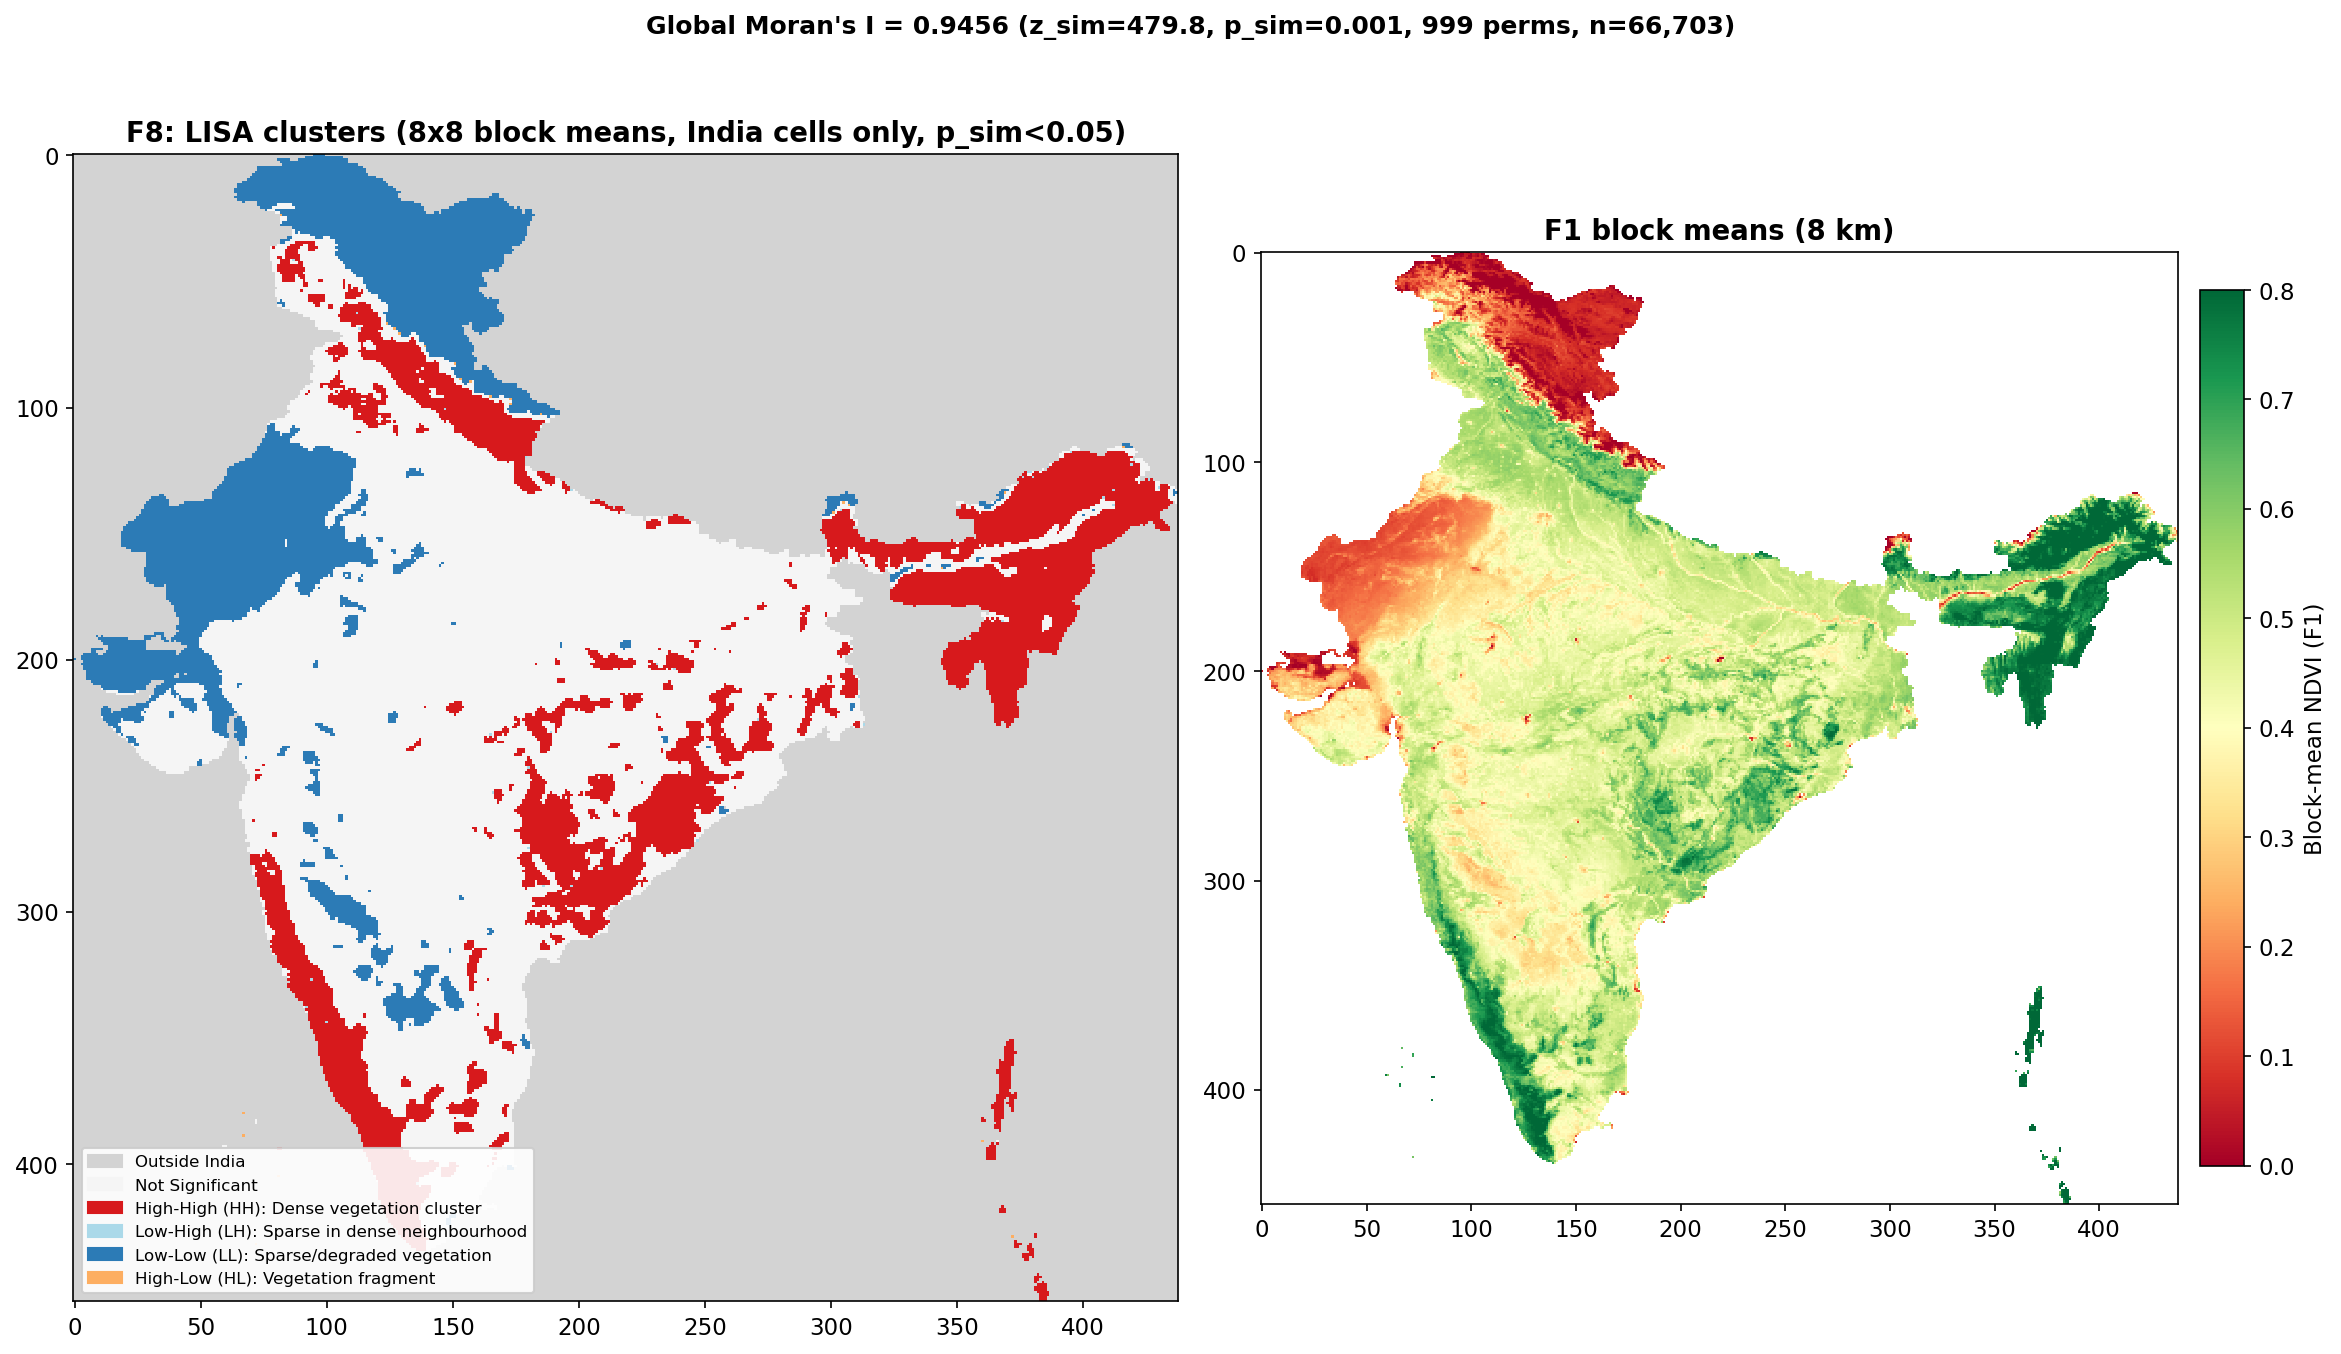

[OK] Moran's I / LISA complete


In [12]:
B = LISA_BLOCK
Hb, Wb = H // B, W // B
print(f"Computing spatial autocorrelation on {B}x{B} block means of F1 ({Hb} x {Wb} blocks)...")
blk = np.nanmean(F1_grid[:Hb * B, :Wb * B].reshape(Hb, B, Wb, B), axis=(1, 3))
keep_blocks = np.flatnonzero(np.isfinite(blk).ravel())
print(f"  Valid (India) blocks: {keep_blocks.size:,} of {Hb*Wb:,}  (no fill values used)")

w_full = lat2W(Hb, Wb, rook=False)
w_lisa = w_subset(w_full, keep_blocks.tolist(), silence_warnings=True)
w_lisa.transform = 'R'
n_islands = len(w_lisa.islands)
print(f"  Weights: queen lattice subset, n={w_lisa.n:,}, islands={n_islands}, row-standardised")
yb = blk.ravel()[keep_blocks].astype(np.float64)            # esda/numba requires float64

np.random.seed(LISA_SEED)                                   # Moran() has no seed argument
moran_global = Moran(yb, w_lisa, permutations=LISA_GLOBAL_PERMS)
print(f"\n-- Global Moran's I (India-only block means) --")
print(f"  I       = {moran_global.I:.4f}   (audit: 0.9456; E[I] = {moran_global.EI:.2e})")
print(f"  z_sim   = {moran_global.z_sim:.2f}")
print(f"  p_sim   = {moran_global.p_sim:.4f}  ({LISA_GLOBAL_PERMS} permutations)")

print(f"\nComputing Local Moran's I (LISA, {LISA_LOCAL_PERMS} permutations, seed {LISA_SEED})...")
moran_local = Moran_Local(yb, w_lisa, transformation='R', permutations=LISA_LOCAL_PERMS,
                          seed=LISA_SEED, n_jobs=1)
lisa_code = np.where(moran_local.p_sim < LISA_ALPHA, moran_local.q, 0).astype(np.float32)

lisa_blk = np.full(Hb * Wb, np.nan, dtype=np.float32)
lisa_blk[keep_blocks] = lisa_code
lisa_blk = lisa_blk.reshape(Hb, Wb)
F8_grid = np.full((H, W), np.nan, dtype=np.float32)
F8_grid[:Hb * B, :Wb * B] = np.repeat(np.repeat(lisa_blk, B, axis=0), B, axis=1)
F8_grid[~india_mask] = np.nan

labels = {0: 'Not Significant',
          1: 'High-High (HH): Dense vegetation cluster',
          2: 'Low-High (LH): Sparse in dense neighbourhood',
          3: 'Low-Low (LL): Sparse/degraded vegetation',
          4: 'High-Low (HL): Vegetation fragment'}
lisa_counts = {int(q): int((lisa_code == q).sum()) for q in labels}
print(f'\n-- LISA cluster counts (p_sim < {LISA_ALPHA}, blocks) --')
for q, lbl in labels.items():
    print(f'  {lbl:<45s}: {lisa_counts[q]:>7,}  ({100*lisa_counts[q]/keep_blocks.size:.1f}%)')
RUN_SUMMARY['F8_moran'] = dict(I=float(moran_global.I), EI=float(moran_global.EI), z_sim=float(moran_global.z_sim),
                               p_sim=float(moran_global.p_sim), permutations=LISA_GLOBAL_PERMS,
                               n_blocks=int(keep_blocks.size), n_islands=int(n_islands),
                               block_size_px=B, lisa_counts=lisa_counts)

colors = {-1: '#D3D3D3', 0: '#F5F5F5', 1: '#d7191c', 2: '#abd9e9', 3: '#2c7bb6', 4: '#fdae61'}
lab_all = {-1: 'Outside India', **labels}
lisa_plot = np.where(np.isnan(lisa_blk), -1, lisa_blk)
sorted_keys = sorted(colors.keys())
cmap = mcolors.ListedColormap([colors[k] for k in sorted_keys])
norm = mcolors.BoundaryNorm([k - 0.5 for k in sorted_keys] + [sorted_keys[-1] + 0.5], cmap.N)
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
axes[0].imshow(lisa_plot, cmap=cmap, norm=norm, interpolation='nearest', origin='upper')
axes[0].legend(handles=[Patch(color=colors[k], label=lab_all[k]) for k in sorted_keys],
               loc='lower left', fontsize=8, framealpha=0.9)
axes[0].set_title(f'F8: LISA clusters ({B}x{B} block means, India cells only, p_sim<{LISA_ALPHA})', fontweight='bold')
im2 = axes[1].imshow(blk, cmap='RdYlGn', vmin=0.0, vmax=0.8, interpolation='nearest', origin='upper')
plt.colorbar(im2, ax=axes[1], label='Block-mean NDVI (F1)', shrink=0.7, pad=0.02)
axes[1].set_title(f'F1 block means ({B} km)', fontweight='bold')
plt.suptitle(f"Global Moran's I = {moran_global.I:.4f} (z_sim={moran_global.z_sim:.1f}, "
             f"p_sim={moran_global.p_sim:.3f}, {LISA_GLOBAL_PERMS} perms, n={keep_blocks.size:,})",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'F8_LISA_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Moran's I / LISA complete")


## Step 10 -- Diagnostic (not a feature): NDVI-Fire Breakpoint theta\*
A piecewise logistic P(fire | F1) with an empirically fitted breakpoint theta\*, on real fire/no-fire
pixel labels (containing-pixel rule), nationally and per biogeographic zone, balanced case-control
subsample. **v2: not exported as a feature.** A 0/1 indicator `F1 < theta*` is a step function of
F1 whose cut point was fitted on the same labels the model predicts -- it adds no information over
F1 (audit: Delta-AUC 0.0000) and leaks the label. theta\* is retained here only as a descriptive result
(audit: 0.5239 with corrected labels; 0.5370 on training labels only).

Fitting NDVI-fire breakpoint threshold (diagnostic only) using corrected Step 1 labels...


  All India           : theta* = 0.5272  (n=200,000: 100,000 fire / 100,000 no-fire)
   (audit, corrected labels: 0.5239)

Zone-stratified breakpoint thresholds (diagnostic):


  Western_Ghats       : theta* = 0.4815  (n=116,208: 16,208 fire / 100,000 no-fire)  [11/25 starts degenerate, excluded]


  Northeast           : theta* = 0.6460  (n=200,000: 100,000 fire / 100,000 no-fire)


  Himalayan           : theta* = 0.5593  (n=126,882: 26,882 fire / 100,000 no-fire)  [1/25 starts degenerate, excluded]


  Central_India       : theta* = 0.5103  (n=181,147: 81,147 fire / 100,000 no-fire)


  Deccan              : theta* = 0.5036  (n=118,765: 18,765 fire / 100,000 no-fire)  [4/25 starts degenerate, excluded]

Zone threshold summary: {'Western_Ghats': 0.4815, 'Northeast': 0.646, 'Himalayan': 0.5593, 'Central_India': 0.5103, 'Deccan': 0.5036}


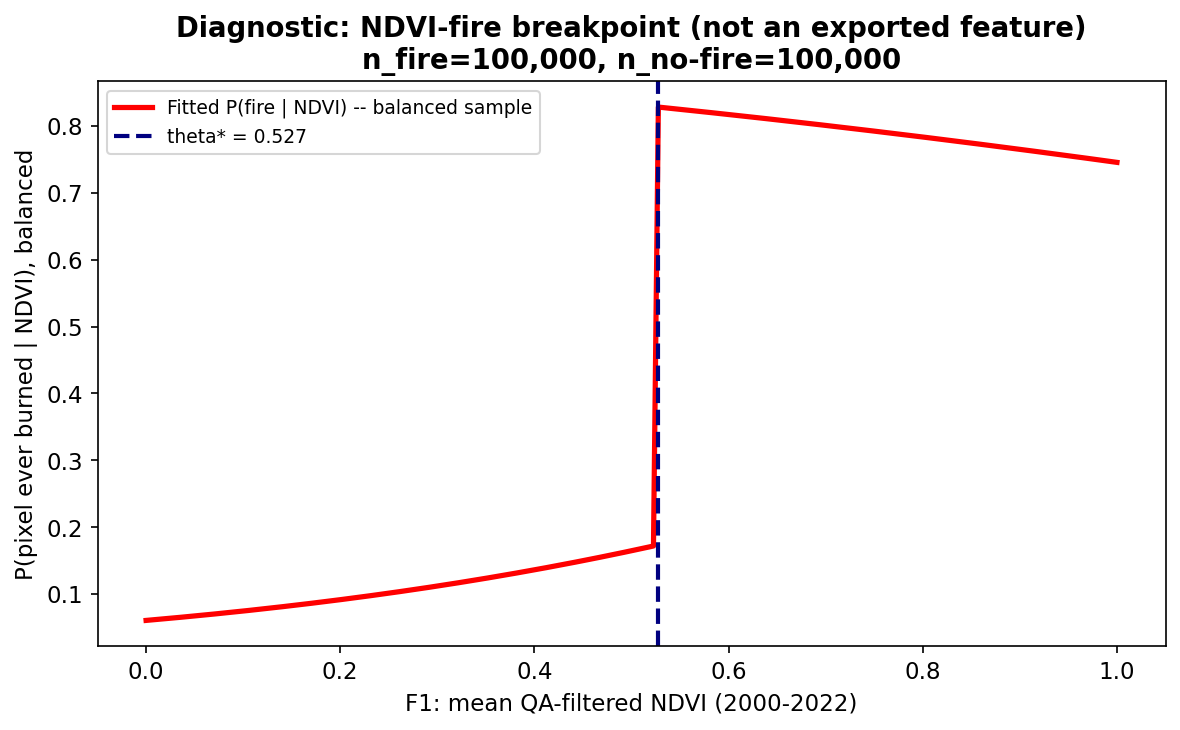


[OK] Breakpoint diagnostic complete (no GeoTIFF written)


In [13]:
print("Fitting NDVI-fire breakpoint threshold (diagnostic only) using corrected Step 1 labels...")

def piecewise_logistic_nll(params, x, y):
    a1, b1, a2, b2, theta = params
    prob = np.where(x <= theta, expit(a1 + b1*x), expit(a2 + b2*x))
    prob = np.clip(prob, 1e-7, 1 - 1e-7)
    return -np.sum(y*np.log(prob) + (1-y)*np.log(1-prob))


def find_ndvi_threshold(ndvi_vals, fire_labels, zone_name='All India', n_theta=25, max_n=200_000, seed=42,
                         degenerate_floor=0.01):
    # Multi-start Nelder-Mead fit of a piecewise-logistic breakpoint theta*, bounded to the valid NDVI range.
    # Solutions where one regime holds < degenerate_floor of the sample are regime collapses (theta not
    # identifiable) and are excluded; if all starts collapse, no threshold is reported for the zone.
    valid = ~np.isnan(ndvi_vals)
    x, y = ndvi_vals[valid], fire_labels[valid]
    if len(x) < 200 or y.sum() < 30:
        print(f'  [!!] Insufficient data for {zone_name} (n={len(x):,}, fires={int(y.sum()):,})')
        return None, None, None

    rng = np.random.RandomState(seed)
    pos_idx, neg_idx = np.where(y == 1)[0], np.where(y == 0)[0]
    n_pos = min(len(pos_idx), max_n // 2)
    n_neg = min(len(neg_idx), max_n // 2)
    idx = np.concatenate([rng.choice(pos_idx, n_pos, replace=False),
                           rng.choice(neg_idx, n_neg, replace=False)])
    xs, ys = x[idx], y[idx]

    theta_grid = np.linspace(np.percentile(xs, 10), np.percentile(xs, 90), n_theta)
    param_bounds = [(None, None), (None, None), (None, None), (None, None),
                     (NDVI_VALID_MIN, NDVI_VALID_MAX)]
    n_total = len(xs)
    floor_n = max(1, int(degenerate_floor * n_total))

    best_nll, best_theta, best_params = np.inf, None, None
    n_degenerate, n_attempted = 0, 0
    for theta_init in theta_grid:
        try:
            res = minimize(piecewise_logistic_nll, [0., -1., 0., -0.5, theta_init], args=(xs, ys),
                            method='Nelder-Mead', bounds=param_bounds,
                            options={'maxiter': 500, 'xatol': 1e-4})
        except Exception:
            continue
        n_attempted += 1
        theta_res = res.x[4]
        n_below = int(np.sum(xs <= theta_res))
        if n_below < floor_n or n_total - n_below < floor_n:
            n_degenerate += 1
            continue
        if res.fun < best_nll:
            best_nll, best_theta, best_params = res.fun, theta_res, res.x

    if best_theta is None:
        print(f'  [!!] {zone_name:20s}: no stable interior breakpoint ({n_degenerate}/{n_attempted} starts degenerate)')
        return None, None, (n_pos, n_neg)
    degeneracy_note = f'  [{n_degenerate}/{n_attempted} starts degenerate, excluded]' if n_degenerate else ''
    print(f'  {zone_name:20s}: theta* = {best_theta:.4f}  (n={len(xs):,}: {n_pos:,} fire / {n_neg:,} no-fire)'
          f'{degeneracy_note}')
    return best_theta, best_params, (n_pos, n_neg)


fire_label_map = fire_ever_mask.astype(np.int8)
theta_india, params_india, n_india = find_ndvi_threshold(F1_grid.ravel(), fire_label_map.ravel(), 'All India')
print('   (audit, corrected labels: 0.5239)')

lons_1d = c + a * (np.arange(W) + 0.5)          # pixel CENTRES
lats_1d = f + e * (np.arange(H) + 0.5)
zone_thresholds = {}
print('\nZone-stratified breakpoint thresholds (diagnostic):')
for zone, bbox in BIO_ZONES.items():
    rmask = (lats_1d >= bbox['lat_min']) & (lats_1d <= bbox['lat_max'])
    cmask = (lons_1d >= bbox['lon_min']) & (lons_1d <= bbox['lon_max'])
    zmask = rmask[:, None] & cmask[None, :]
    theta_z, _, _ = find_ndvi_threshold(F1_grid[zmask], fire_label_map[zmask], zone)
    zone_thresholds[zone] = round(float(theta_z), 4) if theta_z is not None else None
print('\nZone threshold summary:', zone_thresholds)
RUN_SUMMARY['breakpoint_diagnostic'] = dict(theta_india=None if theta_india is None else float(theta_india),
                                            zones=zone_thresholds, exported_as_feature=False)

if theta_india is not None:
    a1, b1, a2, b2, _ = params_india
    ndvi_range = np.linspace(0, 1, 200)
    p_piece = np.where(ndvi_range <= theta_india, expit(a1 + b1*ndvi_range), expit(a2 + b2*ndvi_range))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ndvi_range, p_piece, 'r-', lw=2.5, label='Fitted P(fire | NDVI) -- balanced sample')
    ax.axvline(theta_india, color='navy', ls='--', lw=2, label=f'theta* = {theta_india:.3f}')
    ax.set_xlabel('F1: mean QA-filtered NDVI (2000-2022)'); ax.set_ylabel('P(pixel ever burned | NDVI), balanced')
    ax.set_title(f'Diagnostic: NDVI-fire breakpoint (not an exported feature)\n'
                 f'n_fire={n_india[0]:,}, n_no-fire={n_india[1]:,}', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'diag_NDVI_fire_breakpoint.png', dpi=150, bbox_inches='tight')
    plt.show()
print('\n[OK] Breakpoint diagnostic complete (no GeoTIFF written)')


## Step 11 -- Feature Export (v2 output contract)
Writes the v2 feature GeoTIFFs (float32, NaN nodata, the raw NDVI grid profile -- identical
transform/CRS/shape, so Steps 3-6 keep aligning to `F1_NDVI_QA_mean.tif`). Superseded v1 feature
files are first **moved** (not deleted) into `_superseded_v1/`, so no downstream step can silently
read an invalid v1 feature. A machine-readable run summary (`NDVI_v2_run_summary.json`) records
every headline number for comparison against the audit's `R4_report.json`.

In [14]:
# -- 1. Move superseded v1 outputs out of the feature folder (never deleted) --
SUPERSEDED_DIR = OUT_DIR / '_superseded_v1'
superseded = []
for pat in ['F3_NDVI_anomaly_mean.tif', 'F4_NDVI_trend_2x12MA.tif', 'F5_NDVI_residual_mean.tif',
            'F6_MannKendall_tau.tif', 'F9_NDVI_below_threshold_*.tif',
            'ndvi_trend_mean.npy', 'ndvi_mk_tau.npy', 'ndvi_residual_mean.npy', 'cvsi_k*_mean.npy',
            'F1_F3_NDVI_Anomaly.png', 'F4_F6_Trend_MannKendall.png', 'F9_NDVI_breakpoint.png']:
    superseded += sorted(OUT_DIR.glob(pat))
superseded += [p for p in sorted(OUT_DIR.glob('F7_CVSI_k*.tif')) if p.name != f'F7_CVSI_k{k_star}.tif']
if superseded:
    SUPERSEDED_DIR.mkdir(exist_ok=True)
    for p in superseded:
        os.replace(p, SUPERSEDED_DIR / p.name)
        print(f'  [moved] {p.name} -> _superseded_v1/')
else:
    print('  No superseded v1 files present.')

# -- 2. Write the v2 features --
FEATURE_DEFS = {
    'F1_NDVI_QA_mean': 'Time mean of QA-filtered NDVI (pixel_reliability in {0,1}; VI_Quality MODLAND in {0,1} '
                       'for months without a reliability layer), 266 months 2000-11..2022-12, India mask',
    'F2_NDVI_climatological_June': 'Mean QA-filtered NDVI of the June months 2001-2020',
    'F6_NDVI_SeasonalKendall_tau': 'Seasonal Kendall tau (Hirsch et al. 1982) on monthly QA-filtered NDVI',
    'F6_NDVI_SeasonalKendall_qvalue': f'Benjamini-Hochberg q of the Seasonal Kendall test (tie-corrected variance, '
                                      f'continuity-corrected normal p, >= {SK_MIN_PAIRS} within-month pairs), over India pixels',
    'F6_NDVI_Sen_slope': 'Seasonal Sen slope, median within-calendar-month pairwise slope, NDVI per year',
    f'F7_CVSI_k{k_star}': f'Time mean of CVSI(t,k*={k_star}) = sum_(lag=1..k*) max(-anomaly_(t-lag),0) vs 2001-2020 '
                          f'climatology; k* = argmax mean MI over 5 background draws',
    'F8_LISA_cluster': f'Local Moran quadrant (1 HH, 2 LH, 3 LL, 4 HL, 0 n.s. at p_sim<{LISA_ALPHA}) on {B}x{B} block '
                       f'means of F1, India cells only, queen weights, {LISA_LOCAL_PERMS} perms; NaN outside India',
    'F10_fire_count_Step1': 'Step 1 fire-point count per containing pixel: col=floor((lon-c)/a), row=floor((lat-f)/e)',
}
FEATURE_ARRAYS = {
    'F1_NDVI_QA_mean': F1_grid,
    'F2_NDVI_climatological_June': F2_grid,
    'F6_NDVI_SeasonalKendall_tau': F6_tau_grid,
    'F6_NDVI_SeasonalKendall_qvalue': F6_q_grid,
    'F6_NDVI_Sen_slope': F6_sen_grid,
    f'F7_CVSI_k{k_star}': F7_grid,
    'F8_LISA_cluster': F8_grid,
    'F10_fire_count_Step1': fire_count_map.astype(np.float32),
}


def save_feature_geotiff(array_2d, feature_name, meta, out_dir):
    assert array_2d.shape == (H, W), f'{feature_name}: shape {array_2d.shape} != grid {(H, W)}'
    out_path = out_dir / f'{feature_name}.tif'
    m = meta.copy()
    m.update({'count': 1, 'dtype': 'float32', 'nodata': np.nan, 'compress': 'lzw'})
    with rasterio.open(out_path, 'w', **m) as dst:
        dst.write(array_2d.astype(np.float32), 1)
        dst.update_tags(FEATURE=feature_name, DEFINITION=FEATURE_DEFS[feature_name],
                        VERSION='v2 (2026-09-25 methodology audit)', SOURCE='MOD13A3.061',
                        PERIOD=f'{STUDY_START.date()} to {STUDY_END.date()}',
                        REFERENCE='Step 2 of the India fire-risk pipeline; extends Biswas et al. 2025')
    print(f'  [OK] Saved: {feature_name}.tif  (finite px: {int(np.isfinite(array_2d).sum()):,})')
    return out_path


print(f'\nExporting v2 features as GeoTIFFs to {OUT_DIR}\n')
feature_paths = {name: save_feature_geotiff(arr, name, meta_ref, OUT_DIR) for name, arr in FEATURE_ARRAYS.items()}

# -- 3. Run summary --
RUN_SUMMARY['feature_files'] = sorted(p.name for p in feature_paths.values())
RUN_SUMMARY['other_outputs'] = ['F7_CVSI_MI_lag_sweep.csv', 'india_mask.npy', 'fire_count_map.npy']
RUN_SUMMARY['superseded_moved'] = [p.name for p in superseded]
RUN_SUMMARY['compute'] = f'GPU ({gpu_name})' if GPU_AVAILABLE else 'CPU (NumPy fallback)'
RUN_SUMMARY['runtime_sec'] = round(time.time() - T0_NOTEBOOK, 1)
with open(OUT_DIR / 'NDVI_v2_run_summary.json', 'w', encoding='utf-8') as fh:
    json.dump(RUN_SUMMARY, fh, indent=1, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
print(f'\n[OK] {len(feature_paths)} v2 feature GeoTIFFs + NDVI_v2_run_summary.json written to {OUT_DIR}')


  [moved] F3_NDVI_anomaly_mean.tif -> _superseded_v1/
  [moved] F4_NDVI_trend_2x12MA.tif -> _superseded_v1/
  [moved] F5_NDVI_residual_mean.tif -> _superseded_v1/
  [moved] F6_MannKendall_tau.tif -> _superseded_v1/
  [moved] F9_NDVI_below_threshold_0.535.tif -> _superseded_v1/
  [moved] ndvi_trend_mean.npy -> _superseded_v1/
  [moved] ndvi_mk_tau.npy -> _superseded_v1/
  [moved] ndvi_residual_mean.npy -> _superseded_v1/
  [moved] cvsi_k6_mean.npy -> _superseded_v1/
  [moved] cvsi_k8_mean.npy -> _superseded_v1/
  [moved] F1_F3_NDVI_Anomaly.png -> _superseded_v1/
  [moved] F4_F6_Trend_MannKendall.png -> _superseded_v1/
  [moved] F9_NDVI_breakpoint.png -> _superseded_v1/

Exporting v2 features as GeoTIFFs to D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs



  [OK] Saved: F1_NDVI_QA_mean.tif  (finite px: 4,160,768)


  [OK] Saved: F2_NDVI_climatological_June.tif  (finite px: 4,155,065)


  [OK] Saved: F6_NDVI_SeasonalKendall_tau.tif  (finite px: 4,159,040)


  [OK] Saved: F6_NDVI_SeasonalKendall_qvalue.tif  (finite px: 4,153,368)


  [OK] Saved: F6_NDVI_Sen_slope.tif  (finite px: 4,159,040)


  [OK] Saved: F7_CVSI_k8.tif  (finite px: 4,151,704)


  [OK] Saved: F8_LISA_cluster.tif  (finite px: 4,173,440)
  [OK] Saved: F10_fire_count_Step1.tif  (finite px: 12,758,064)

[OK] 8 v2 feature GeoTIFFs + NDVI_v2_run_summary.json written to D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs


## Step 12 -- Summary

In [15]:
print('='*78)
print('NDVI FEATURE SUMMARY -- Step 2 v2 (linked to Step 1)')
print('='*78)
summary = [
    ('F1',  'QA-filtered NDVI mean',          f"QA gap closed (VI_Quality MODLAND for {len(qa_substitute_log)} months)"),
    ('F2',  'June climatology 2001-2020',     'baseline 2001-2020'),
    ('F6',  'Seasonal Kendall tau / q / Sen', f"FDR greening {sk_stats['sig_fdr_greening']:,} / browning {sk_stats['sig_fdr_browning']:,}; "
                                              f"median Sen {sk_stats['sen_median_per_yr']:+.5f}/yr"),
    ('F7',  f'CVSI (k*={k_star})',            'k* = argmax mean MI (5 draws) on corrected fire labels'),
    ('F8',  'LISA cluster (8 km blocks)',     f"India-only block means; global I = {moran_global.I:.4f} (p_sim {moran_global.p_sim:.3f})"),
    ('F10', 'Fire count (containing pixel)',  f"{fire_stats['fire_pixels_full_grid']:,} fire pixels, {fire_stats['n_points_sum_raster']:,} points"),
    ('--',  'Dropped (v1 F3/F4/F5/F6-MK/F9)', 'degenerate / redundant / invalid test / label-derived'),
]
print(f'{"#":<5} {"Feature":<34} {"Status"}')
print('-'*78)
for fid, name, status in summary:
    print(f'{fid:<5} {name:<34} {status}')
print('='*78)
print(f'Study period       : {STUDY_START.date()} -> {STUDY_END.date()}  (matches Step 1)')
print(f'Compute            : {"GPU (" + gpu_name + ")" if GPU_AVAILABLE else "CPU (NumPy fallback)"}')
print(f'Fire points used   : {len(fire_df):,}  (Step 1 real extraction)')
print(f'Breakpoint theta*  : {theta_india if theta_india is None else round(float(theta_india), 4)}  (diagnostic only, not exported)')
print(f'Outputs            : {OUT_DIR}')
print(f'Total runtime      : {(time.time() - T0_NOTEBOOK)/60:.1f} min')
print('='*78)


NDVI FEATURE SUMMARY -- Step 2 v2 (linked to Step 1)
#     Feature                            Status
------------------------------------------------------------------------------
F1    QA-filtered NDVI mean              QA gap closed (VI_Quality MODLAND for 2 months)
F2    June climatology 2001-2020         baseline 2001-2020
F6    Seasonal Kendall tau / q / Sen     FDR greening 3,552,278 / browning 72,305; median Sen +0.00262/yr
F7    CVSI (k*=8)                        k* = argmax mean MI (5 draws) on corrected fire labels
F8    LISA cluster (8 km blocks)         India-only block means; global I = 0.9456 (p_sim 0.001)
F10   Fire count (containing pixel)      268,766 fire pixels, 541,545 points
--    Dropped (v1 F3/F4/F5/F6-MK/F9)     degenerate / redundant / invalid test / label-derived
Study period       : 2000-11-01 -> 2022-12-15  (matches Step 1)
Compute            : GPU (NVIDIA RTX PRO 4500 Blackwell)
Fire points used   : 541,545  (Step 1 real extraction)
Breakpoint theta*  : 0.5